# Problem Statement
The e-commerce business is quite popular today. Here, you do not need to take orders by going to each customer. A company launches its website to sell the items to the end consumer, and customers can order the products that they require from the same website. Famous examples of such e-commerce companies are Amazon, Flipkart, Myntra, Paytm and Snapdeal.



Suppose you are working as a Machine Learning Engineer in an e-commerce company named 'Ebuss'. Ebuss has captured a huge market share in many fields, and it sells the products in various categories such as household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products and health care products.



With the advancement in technology, it is imperative for Ebuss to grow quickly in the e-commerce market to become a major leader in the market because it has to compete with the likes of Amazon, Flipkart, etc., which are already market leaders.



As a senior ML Engineer, you are asked to build a model that will improve the recommendations given to the users given their past reviews and ratings.



In order to do this, you planned to build a sentiment-based product recommendation system, which includes the following tasks.

    Data sourcing and sentiment analysis
    Building a recommendation system
    Improving the recommendations using the sentiment analysis model
    Deploying the end-to-end project with a user interface



    Data sourcing and sentiment analysis

In this task, you have to analyse product reviews after some text preprocessing steps and build an ML model to get the sentiments corresponding to the users' reviews and ratings for multiple products.



The dataset that you are going to use is inspired by this Kaggle competition. We have made a subset of the original dataset, which has been provided below.



Product Reviews Dataset



This dataset consists of 30,000 reviews for more than 200 different products. The reviews and ratings are given by more than 20,000 users. Please refer to the following attribute description file to get the details about the columns of the Review Dataset.



Product Reviews Dataset- Attribute Description



The steps to be performed for the first task are given below.

    Exploratory data analysis

    Data cleaning

    Text preprocessing

    Feature extraction: In order to extract features from the text data, you may choose from any of the methods, including bag-of-words, TF-IDF vectorization or word embedding.

    Training a text classification model: You need to build at least three ML models. You then need to analyse the performance of each of these models and choose the best model. At least three out of the following four models need to be built (Do not forget, if required, handle the class imbalance and perform hyperparameter tuning.).
    1. Logistic regression
    2. Random forest
    3. XGBoost
    4. Naive Bayes

Out of these four models, you need to select one classification model based on its performance.

    Building a recommendation system

As you learnt earlier, you can use the following types of recommendation systems.



1. User-based recommendation system

2. Item-based recommendation system



Your task is to analyse the recommendation systems and select the one that is best suited in this case.



Once you get the best-suited recommendation system, the next task is to recommend 20 products that a user is most likely to purchase based on the ratings. You can use the 'reviews_username' (one of the columns in the dataset) to identify your user.



    Improving the recommendations using the sentiment analysis model

Now, the next task is to link this recommendation system with the sentiment analysis model that was built earlier (recall that we asked you to select one ML model out of the four options). Once you recommend 20 products to a particular user using the recommendation engine, you need to filter out the 5 best products based on the sentiments of the 20 recommended product reviews.



In this way, you will get an ML model (for sentiments) and the best-suited recommendation system. Next, you need to deploy the entire project publically.



    Deployment of this end to end project with a user interface

Once you get the ML model and the best-suited recommendation system, you will deploy the end-to-end project. You need to use the Flask framework, which is majorly used to create web applications to deploy machine learning models.



Next, you need to include the following features in the user interface.

    Take any of the existing usernames as input.
    Create a submit button to submit the username.
    Once you press the submit button, it should recommend 5 products based on the entered username.

Note: An important point that you need to consider here is that the number of users and the number of products are fixed in this case study, and you are doing the sentiment analysis and building the recommendation system only for those users who have already submitted the reviews or ratings corresponding to some of the products in the dataset.



Because the dataset that you are going to use is huge, the model training may take time, and hence, you can use Google Colab to directly code or upload the already created notebook.



You can look into the user guide to access the Colab below.



Colab User Guide



Assumption: No new users or products will be introduced or considered when building or predicting from the models built.



What needs to be submitted for the evaluation of the project?

    An end-to-end Jupyter Notebook, which consists of the entire code (data cleaning steps, text preprocessing, feature extraction, ML models used to build sentiment analysis models, two recommendation systems and their evaluations, etc.) of the problem statement defined
    The following deployment files

    One 'model.py' file, which should contain only one ML model and only one recommendation system that you have obtained from the previous steps along with the entire code to deploy the end-to-end project using Flask and Heroku
    'index.html' file, which includes the HTML code of the user interface
    'app.py' file, which is the Flask file to connect the backend ML model with the frontend HTML code
    Supported pickle files, which have been generated while pickling the models

The evaluation rubrics are mentioned in the next segment.

Let's start with the sentiment analysis model. Based on the product reviews, you can build a machine learning model that can give the corresponding sentiments of each of the products present in the data. An outline of the steps required to do this is given below.

1. Data sourcing

2. Data cleaning, to handle missing values and to remove unnecessary columns

3. Text preprocessing, including tokenisation, punctuation and stopwords removal, noise removal, lemmatization and spell correction, etc

4. Feature extraction or feature creation using bag-of-words, TF-IDF or word embedding techniques

5. Training of text classification models for sentiment analysis using the ML techniques such as logistic regression, random forest, XGBoost and Naive Bayes algorithm

6. Evaluation and comparing the results of multiple ML models built and choosing the one that outperforms the others


##  Importing Libraries


In [25]:
# Supress unnecessary warnings
import warnings

import pandas as pd

pd.options.display.max_columns = None

warnings.filterwarnings("ignore")
from IPython.display import display

pd.set_option("max_colwidth", 500)

import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")
import string

# general purpose libraries
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.precision", 2)

[nltk_data] Downloading package stopwords to /Users/deven/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/deven/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/deven/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/deven/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/deven/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [26]:
# general purpose libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import warnings
from imblearn.over_sampling import SMOTE
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.precision", 2)

In [27]:
# NLTK libraries

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import wordnet

[nltk_data] Downloading package stopwords to /Users/deven/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/deven/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/deven/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/deven/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/deven/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [28]:
# Modelling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

## 1 Data Cleaning and Pre-Processing

In [11]:
os.chdir("data")

In [6]:
# os.chdir('../')

In [12]:
df = pd.read_csv("sample30.csv")

In [13]:
def display_info(dataframe):
    display(dataframe[:10])
    print("\n\n")
    dataframe.info()

In [14]:
display_info(df)

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,NaN,NaN,walker557,Negative
5,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-04-20T00:00:00.000Z,False,False,1,My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.,Not worth it,NaN,NaN,samantha,Negative
6,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-02-08T00:00:00.000Z,False,False,1,Bought this earlier today and was excited to check it out. Based on the product description I was expecting something but it was just like the regular KY. We are fans of the his and hers so we just expected more and were left a little disappointed.,Disappointing,NaN,NaN,raeanne,Negative
7,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-02-21T00:00:00.000Z,False,False,1,I bought this product for my husband and I to try and we were not impressed at all. There was no tingling or warming. It left us both very sticky. I have used KY products in the past (loved KY his and hers) but this one was disappointing.,Not happy at all,NaN,NaN,kimmie,Negative
8,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-03-28T00:00:00.000Z,False,False,1,My husband and I bought this for some extra fun. We werevboth extremely disappointed. Especially for the price! Do not waste your money on this product. We f




<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  str   
 1   brand                 30000 non-null  str   
 2   categories            30000 non-null  str   
 3   manufacturer          29859 non-null  str   
 4   name                  30000 non-null  str   
 5   reviews_date          29954 non-null  str   
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  str   
 10  reviews_title         29810 non-null  str   
 11  reviews_userCity      1929 non-null   str   
 12  reviews_userProvince  170 non-null    str   
 13  reviews_username      29937 non-null  str   
 14  user_sentiment        29999 non-null  str   
dtypes: int64(1), object(2), str(12)
memory usage

In [15]:
dfAnalysis = df.copy()

In [16]:
dfAnalysis = dfAnalysis[~dfAnalysis["reviews_date"].isna()]
dfAnalysis = dfAnalysis[
    dfAnalysis["reviews_date"].apply(
        lambda x: x != ' hooks slide or swivel into any desired position."'
    )
]
dfAnalysis.shape

(29946, 15)

In [17]:
dfAnalysis["reviews_date"] = pd.to_datetime(dfAnalysis["reviews_date"], unit="D")
dfAnalysis["review_year"] = dfAnalysis["reviews_date"].dt.year
dfAnalysis["review_month"] = dfAnalysis["reviews_date"].dt.month
dfAnalysis["review_day"] = dfAnalysis["reviews_date"].dt.day

In [18]:
dfAnalysis[:4]

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_year,review_month,review_day
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30 06:21:45+00:00,NaN,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,Positive,2012,11,30
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,Positive,2017,7,9
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive,2017,7,9
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06 00:00:00+00:00,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Disappointed,NaN,NaN,rebecca,Negative,2016,1,6


In [19]:
dfAnalysis1 = dfAnalysis.copy()

In [20]:
# Write code to display all the columns with their unique values and counts and check for redundant values
def unique_values_percentage_summary(df, columns):
    """
    A function to calculate the summary of categorical columns of a dataframe
        @param: df -> DataFrame
        @param: columns: list of categorical columns in the dataframe
        @returns: dictionary of summary of unique value counts and their percentages
    """
    if type(columns) is pd.DataFrame:
        columns = columns.columns.tolist()
    elif type(columns) == "set":
        columns = list(columns)

    for column in columns:
        # Count unique values and calculate percentages
        value_counts = df[column].value_counts()
        percentages = df[column].value_counts(normalize=True) * 100

        # Combine counts and percentages into a DataFrame
        unique_summary = pd.DataFrame(
            {"Count": value_counts, "Percentage (%)": percentages}
        )
        display(unique_summary)
        # display(unique_summary)
        # Add the result to the dictionary

    # return results

In [21]:
unique_values_percentage_summary(
    dfAnalysis, dfAnalysis[["brand", "manufacturer", "reviews_rating"]].columns.tolist()
)

,Count,Percentage (%)
brand,,
Clorox,10585,3.53e+01
Warner Home Video,3325,1.11e+01
Disney,1200,4.01e+00
L'oreal Paris,1186,3.96e+00
FOX,887,2.96e+00
...,...,...
Noosa,1,3.34e-03
Southern Enterprises,1,3.34e-03
National Mfg.,1,3.34e-03


,Count,Percentage (%)
manufacturer,,
Clorox,8546,2.87e+01
Test,3325,1.12e+01
AmazonUs/CLOO7,2039,6.84e+00
L'oreal Paris,1232,4.13e+00
Walt Disney,1143,3.83e+00
...,...,...
Unfi,1,3.36e-03
Southern Enterprises,1,3.36e-03
Stanley Hardware,1,3.36e-03


,Count,Percentage (%)
reviews_rating,,
5,20799,69.46
4,6015,20.09
1,1382,4.61
3,1337,4.46
2,413,1.38


In [180]:
unique_values_percentage_summary(
    dfAnalysis,
    dfAnalysis[
        ["reviews_rating", "reviews_didPurchase", "reviews_doRecommend"]
    ].columns.tolist(),
)

,Count,Percentage (%)
reviews_rating,,
5,20799,69.46
4,6015,20.09
1,1382,4.61
3,1337,4.46
2,413,1.38


,Count,Percentage (%)
reviews_didPurchase,,
False,14493,91.01
True,1431,8.99


,Count,Percentage (%)
reviews_doRecommend,,
True,25872,94.35
False,1550,5.65


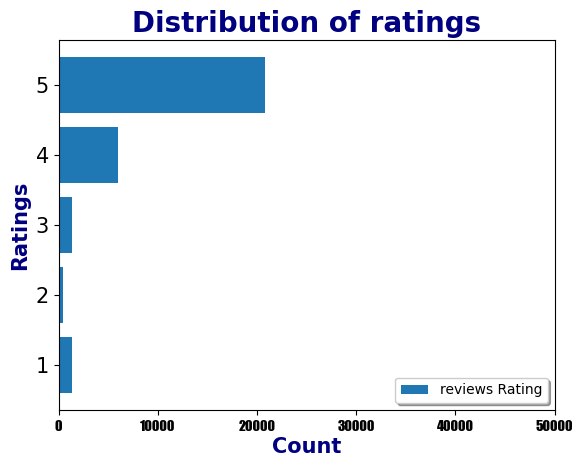

In [22]:
x = list(dfAnalysis["reviews_rating"].value_counts().index)
y = list(dfAnalysis["reviews_rating"].value_counts())
plt.barh(x, y)
ticks_x = np.linspace(0, 50000, 6)  # (start, end, no of ticks)
plt.xticks(ticks_x, fontsize=10, family="fantasy", color="black")
plt.yticks(size=15)

plt.title(
    "Distribution of ratings", fontsize=20, weight="bold", color="navy", loc="center"
)
plt.xlabel("Count", fontsize=15, weight="bold", color="navy")
plt.ylabel("Ratings", fontsize=15, weight="bold", color="navy")
plt.legend(["reviews Rating"], shadow=True, loc=4)
plt.show()

In [182]:
dfAnalysis["reviews_rating"].describe()

count    29946.00
mean         4.48
std          0.99
min          1.00
25%          4.00
50%          5.00
75%          5.00
max          5.00
Name: reviews_rating, dtype: float64

In [183]:
dfAnalysis["reviews_rating"].fillna(dfAnalysis["reviews_rating"].mode()).describe()

count    29946.00
mean         4.48
std          0.99
min          1.00
25%          4.00
50%          5.00
75%          5.00
max          5.00
Name: reviews_rating, dtype: float64

In [184]:
dfAnalysis["reviews_rating"] = dfAnalysis["reviews_rating"].fillna(
    dfAnalysis["reviews_rating"].mode()
)

In [185]:
dfAnalysis["reviews_didPurchase"].isna().sum()

np.int64(14022)

In [186]:
dfAnalysis["reviews_didPurchase"].value_counts()

reviews_didPurchase
False    14493
True      1431
Name: count, dtype: int64

In [187]:
dfAnalysis1 = dfAnalysis.copy()

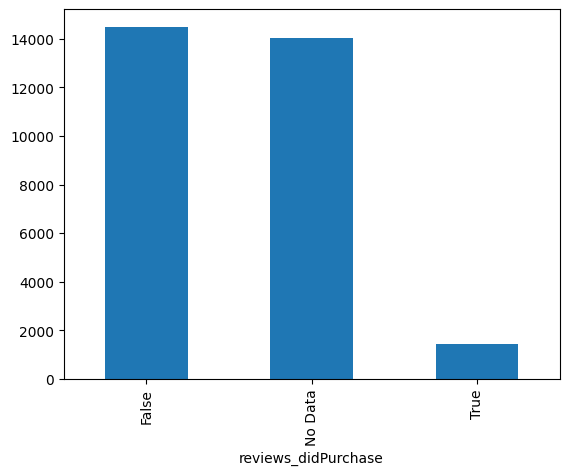

In [188]:
dfAnalysis["reviews_didPurchase"] = dfAnalysis["reviews_didPurchase"].fillna("No Data")
dfAnalysis["reviews_didPurchase"].value_counts().plot.bar()

plt.show()

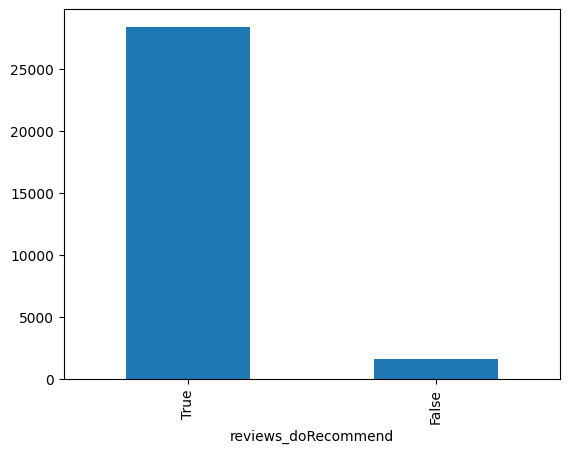

In [189]:
dfAnalysis["reviews_doRecommend"] = dfAnalysis["reviews_doRecommend"].fillna(
    dfAnalysis["reviews_doRecommend"].mode()[0]
)
dfAnalysis["reviews_doRecommend"].value_counts().plot.bar()
plt.show()

In [190]:
# todo dfAnalysis['reviews_doRecommend'].astype(bool)

In [191]:
dfAnalysis[dfAnalysis["reviews_didPurchase"] == "No Data"][
    ["reviews_title", "reviews_text", "reviews_rating", "reviews_doRecommend"]
]

,reviews_title,reviews_text,reviews_rating,reviews_doRecommend
0,Just Awesome,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,5,True
30,Yummilicious And...,"yes, the scent is the best. if you like lemon frosting you won't be able to get enough of this lotion. but also, it's almost 100 natural, none of the yucky ingredients like in major brands of lotion. no mineral oil, no petroleum, etc. but also, it completely works. you know how sometimes you opt...",5,True
37,Still Works,Makes my skin feel clean and not super dry where its ashy if i dont follow with a moisturiser as soon as im done. The skin doesnt feel oily or tacky. Makes my skin more radiant and use of foundation and concealer is not needed to make the skin look even and hydrated.,5,True
43,2 In 1!!!,"Well, Johnson's need I say more I know, right. Ok, but I will. I have used Johnson's since I was a baby, yes it's been a long time. But let's get to the Chase, it's 2 in 1. Come on, who doesn't like 2 in 1 It's hard enough to get the little loves clean, so any help is always a blessing... So, Jo...",4,True
67,Why No Fragrance-Free Formula,"Today is my first time using this product. Felt great going on immediately, felt moisturized without being too greasy. Although it smells great I would have loved to have this formula in a fragrance-free option, my skin tends to be a little sensitive to fragrances, but I will give a final review...",3,True
...,...,...,...,...
29681,Love This Conditioner!,"While I did not find the pre-wash clay mask very useful, I loved the shampoo and conditioner. The scent was wonderful, it had great lather, and my hair felt soft hydrated afterward. My hair continued to feel this way for at least two days. I would definitely use this shampoo and conditioner agai...",5,True
29682,Excellent Product,I really saw a difference in my hair after using all 3 of the products together. I recommend using them together for better results. This stuff really works especially with my hair it tends to get oily after one day of not washing it. This product helps so I can take an extra day of not washing ...,5,True
29683,Great Conditioner!,"After using this conditioner, my hair was really easy to brush. It wasn't stringy or gross. It made my hair smell really great too. I received this product complimentary from Influenster for testing and reviewing purposes. This review was collected as part of a promotion.",5,True
29684,Best Conditioner For Oily Hair,"I received this free for testing purposes, but my opinions are entirely my own. This conditioner was extreme soft, it smelled delicious and it helped keep my dry ends look healthy again! I love everything about this This review was collected as part of a promotion.",5,True


In [192]:
dfAnalysis[dfAnalysis["reviews_didPurchase"] != "No Data"][
    ["reviews_title", "reviews_text", "reviews_rating", "reviews_doRecommend"]
]

,reviews_title,reviews_text,reviews_rating,reviews_doRecommend
1,Good,Good flavor. This review was collected as part of a promotion.,5,True
2,Good,Good flavor.,5,True
3,Disappointed,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",1,False
4,Irritation,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,1,False
5,Not worth it,My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.,1,False
...,...,...,...,...
29995,Softness!!,"I got this conditioner with Influenster to try it and im loving it so far, i have oily hair so i use it only in the ends of my hair and feels amazing, so soft and no mess!! This review was collected as part of a promotion.",5,True
29996,I love it,"I love it , I received this for review purposes from influenster and it leaves my hair feeling fresh and smelling great",5,True
29997,Hair is so smooth after use,First of all I love the smell of this product. After you wash your hair it is so smooth and easy to brush! I did receive this product from influenster for testing purposes but all opinions ARE my own! This review was collected as part of a promotion.,5,True
29998,Perfect for my oily hair!,"I received this through Influenster and will never go back to anything else! I normally don't use conditioner because my hair is so oily and fine. This does not make my hair feel heavy, and it doesn't get oily during the day! It really is fantastic and plan on buying it in the future! This revie...",5,True


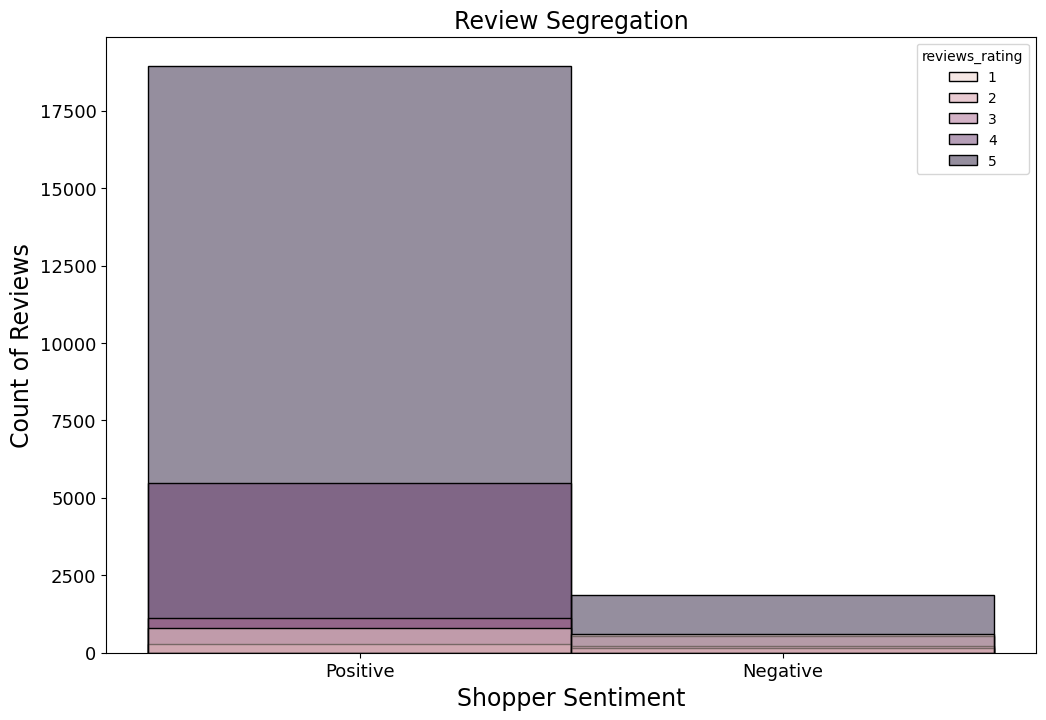

In [193]:
plt.figure(figsize=(12, 8))
ax = sns.histplot(hue=dfAnalysis["reviews_rating"], x=dfAnalysis["user_sentiment"])
ax.set_xlabel(xlabel="Shopper Sentiment", fontsize=17)
ax.set_ylabel(ylabel="Count of Reviews", fontsize=17)
ax.axes.set_title("Review Segregation", fontsize=17)
ax.tick_params(labelsize=13)
plt.show()

In [194]:
df_reviews = dfAnalysis.copy()
# df_reviews = df_reviews.copy()

In [195]:
# df_reviews=[df_reviews['user_sentiment']

In [196]:
df_reviews["user_sentiment"] = df_reviews["user_sentiment"].apply(
    lambda x: 1 if x == "Positive" else 0
)

In [197]:
df_reviews["user_sentiment"].value_counts(normalize=True)

user_sentiment
1    0.89
0    0.11
Name: proportion, dtype: float64

In [198]:
df_reviews.shape

(29946, 18)

In [199]:
# removing nan/null from username
df_reviews = df_reviews[~df_reviews.reviews_username.isna()]

In [200]:
df_reviews[:5]

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_year,review_month,review_day
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30 06:21:45+00:00,No Data,True,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,1,2012,11,30
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,1,2017,7,9
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,Good flavor.,Good,NaN,NaN,dorothy w,1,2017,7,9
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06 00:00:00+00:00,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Disappointed,NaN,NaN,rebecca,0,2016,1,6
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21 00:00:00+00:00,False,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,NaN,NaN,walker557,0,2016,12,21


In [201]:
# Let's combine the reviews_text and reviews_title for better analysis
df_reviews["reviews_title"] = df_reviews["reviews_title"].fillna("")
df_reviews["reviews_full_text"] = (
    df_reviews[["reviews_title", "reviews_text"]]
    .agg(". ".join, axis=1)
    .str.lstrip(". ")
)

In [202]:
df_reviews[:10]

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_year,review_month,review_day,reviews_full_text
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30 06:21:45+00:00,No Data,True,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,1,2012,11,30,Just Awesome. i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,1,2017,7,9,Good. Good flavor. This review was collected as part of a promotion.
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,Good flavor.,Good,NaN,NaN,dorothy w,1,2017,7,9,Good. Good flavor.
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06 00:00:00+00:00,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Disappointed,NaN,NaN,rebecca,0,2016,1,6,"Disappointed. I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation..."
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21 00:00:00+00:00,False,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,NaN,NaN,walker557,0,2016,12,21,Irritation. My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.
5,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-04-20 00:00:00+00:00,False,False,1,My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.,Not worth it,NaN,NaN,samantha,0,2016,4,20,Not worth it. My boyfriend and I bought this to spice things up in the bedroom and we were both highly disappointed in this product. We bought this one because we absolutely love the ky yours and mine and we thought this would have a similar affect but it did absolutely nothing. Do not buy.
6,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-02-08 00:00:00

## 2 Text Preprocessing for Modelling

In [40]:
df_reviews.to_csv("sample_full.csv")

In [41]:
df_reviews_backup = df_reviews.copy()

In [42]:
df_reviews.isna().sum()

id                          0
brand                       0
categories                  0
manufacturer              141
name                        0
reviews_date                0
reviews_didPurchase         0
reviews_doRecommend         0
reviews_rating              0
reviews_text                0
reviews_title               0
reviews_userCity        27989
reviews_userProvince    29722
reviews_username            0
user_sentiment              0
review_year                 0
review_month                0
review_day                  0
reviews_full_text           0
dtype: int64

In [43]:
unique_values_percentage_summary(
    df_reviews,
    df_reviews[
        [
            "user_sentiment",
            "reviews_rating",
            "reviews_didPurchase",
            "reviews_doRecommend",
        ]
    ].columns.tolist(),
)

,Count,Percentage (%)
user_sentiment,,
1,26538,88.79
0,3351,11.21


,Count,Percentage (%)
reviews_rating,,
5,20763,69.47
4,6006,20.09
1,1371,4.59
3,1337,4.47
2,412,1.38


,Count,Percentage (%)
reviews_didPurchase,,
False,14492,48.49
No Data,13966,46.73
True,1431,4.79


,Count,Percentage (%)
reviews_doRecommend,,
True,28339,94.81
False,1550,5.19


In [44]:
df_reviews["reviews_rating"].value_counts(normalize=True)

reviews_rating
5    0.69
4    0.20
1    0.05
3    0.04
2    0.01
Name: proportion, dtype: float64

In [45]:
df_clean = df_reviews.copy()

In [46]:
df_reviews_backup = df_reviews.copy()

### Before Stemming and Lemmatizing

In [47]:
text = " ".join(df_clean["reviews_full_text"])

vocabulary = Counter(text.split())
print(len(vocabulary))
print(vocabulary.most_common(40))

47864
[('the', 39459), ('I', 36468), ('and', 32787), ('a', 29757), ('to', 23326), ('of', 21279), ('it', 15809), ('was', 15737), ('my', 15329), ('for', 14488), ('is', 13942), ('as', 13716), ('This', 13498), ('this', 13315), ('in', 10590), ('part', 9006), ('review', 8969), ('collected', 8743), ('promotion.', 8741), ('have', 8005), ('that', 7237), ('love', 6841), ('with', 6815), ('use', 6780), ('are', 6397), ('great', 6303), ('on', 6241), ('Great', 6024), ('product', 5801), ('but', 5617), ('The', 5124), ('so', 4948), ('not', 4880), ('you', 4432), ('It', 4416), ('movie', 4371), ('like', 4332), ('all', 4307), ('clean', 4015), ('Clorox', 4013)]


### Applying Stemming and Lemmatization

In [242]:
"""function to clean the text and remove all the unnecessary elements."""

import re


def clean_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub("\[\s*\w*\s*\]", "", text)
    dictionary = "abc".maketrans("", "", string.punctuation)
    text = text.translate(dictionary)
    text = re.sub("\S*\d\S*", "", text)

    return text

In [243]:
df_clean["reviews_text"] = df_clean["reviews_full_text"].apply(lambda x: clean_text(x))
df_clean[["reviews_text", "reviews_full_text"]][:5]

,reviews_text,reviews_full_text
0,just awesome i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it rating all the way her metaphors are just crazy,Just Awesome. i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.
1,good good flavor this review was collected as part of a promotion,Good. Good flavor. This review was collected as part of a promotion.
2,good good flavor,Good. Good flavor.
3,disappointed i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it didnt even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what w...,"Disappointed. I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation..."
4,irritation my husband bought this gel for us the gel caused irritation and it felt like it was burning my skin i wouldnt recommend this gel,Irritation. My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.


In [244]:
df_clean_backup = df_clean.copy()

In [245]:
# df_clean = df_clean_backup.copy()

In [246]:
# visualise the data according to the 'Review Text' character length

In [247]:
# This is a helper function to map NTLK position tags
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


stop_words = set(stopwords.words("english"))


def remove_stopword(text):
    words = [word for word in text.split() if word.isalpha() and word not in stop_words]
    return " ".join(words)


lemmatizer = WordNetLemmatizer()


# Lemmatize the sentence
def lemma_text(text):
    word_pos_tags = nltk.pos_tag(
        word_tokenize(remove_stopword(text))
    )  # Get position tags
    # Map the position tag and lemmatize the word/token
    words = [
        lemmatizer.lemmatize(tag[0], get_wordnet_pos(tag[1]))
        for idx, tag in enumerate(word_pos_tags)
    ]
    return " ".join(words)

In [248]:
df_clean["reviews_text_cleaned"] = df_clean.reviews_text.apply(lambda x: lemma_text(x))

### Generating character length

In [249]:
df_clean["reviews_text_cleaned_length"] = df_clean["reviews_text_cleaned"].apply(len)
df_clean["reviews_full_text_length"] = df_clean["reviews_text_cleaned"].apply(len)

### After Stemming and Lemmatizing

### Word Cloud for cleaned text

In [250]:
from wordcloud import WordCloud


def generate_wordcloud(df, col, label=None):
    """
    df: DataFrame
    label: 1 for True news 0 for fake
    @returns draws the plot
    """
    if not label:
        text = " ".join(df_clean[col])
        title = " Generating Word Cloud"
    else:
        text = " ".join(df[df["user_sentiment"] == label][col])
        # text = df['cleaned_reviews']
        if label == 1:
            title = "Word cloud for Positive Sentiment for" + col + "\n"
        else:
            title = "Word cloud for Negative Sentiment \n" + col + "\n"
    wordcloud = WordCloud(
        stopwords=stop_words,
        width=800,
        height=400,
        background_color="white",
        max_words=200,
        colormap="coolwarm",
    ).generate(text)
    # print(wordcloud)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=30, color="brown")
    plt.show()

### Word Cloud Visualaztion for cleaned text

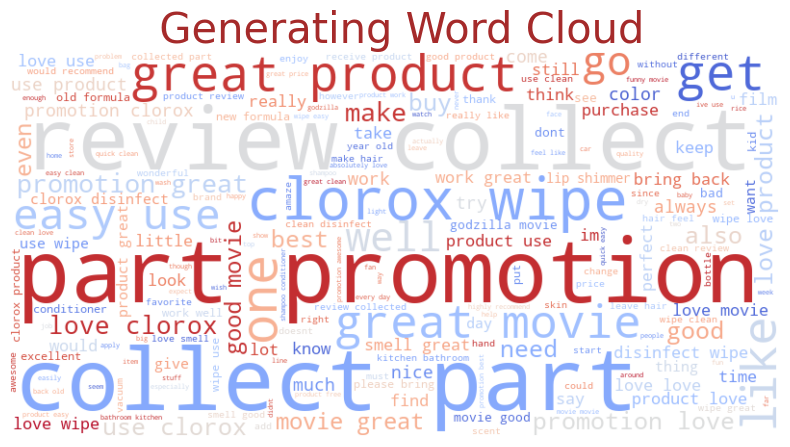

In [251]:
generate_wordcloud(df_clean, "reviews_text_cleaned")

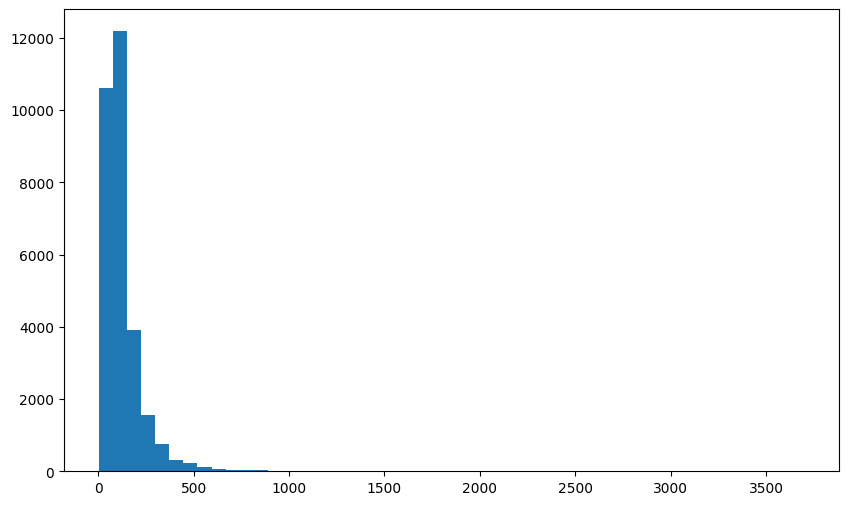

In [252]:
# visualise the data according to the 'Review Text' character length

plt.figure(figsize=(10, 6))

plt.hist(df_clean["reviews_text_cleaned_length"], bins=50)
plt.show()

In [228]:
def get_vocabulary_and_most_common(reviews, top_n):
    text = " ".join(reviews).split()
    return Counter(text).most_common(top_n)

In [230]:
pos_reviews = df_clean[df_clean["user_sentiment"] == 1]
neg_reviews = df_clean[df_clean["user_sentiment"] == 0]
positive_reviews = pos_reviews["reviews_text_cleaned"]
negative_reviews = neg_reviews["reviews_text_cleaned"]

### Positive Reviews Most Common

In [236]:
positive_vocabulary_reviews_40 = get_vocabulary_and_most_common(positive_reviews, 40)
negative_vocabulary_reviews_40 = get_vocabulary_and_most_common(negative_reviews, 40)

In [237]:
positive_vocabulary_reviews_40

[('great', 14472),
 ('love', 12398),
 ('use', 11938),
 ('product', 11367),
 ('movie', 10020),
 ('review', 8575),
 ('part', 8347),
 ('clean', 7951),
 ('promotion', 7945),
 ('wipe', 7605),
 ('collect', 7544),
 ('good', 6923),
 ('clorox', 5453),
 ('like', 4451),
 ('hair', 4449),
 ('smell', 4238),
 ('easy', 4180),
 ('make', 3651),
 ('one', 3564),
 ('get', 3418),
 ('well', 3390),
 ('work', 3004),
 ('best', 2895),
 ('really', 2777),
 ('time', 2549),
 ('godzilla', 2511),
 ('look', 2300),
 ('would', 2274),
 ('go', 2224),
 ('keep', 2199),
 ('feel', 2168),
 ('buy', 2166),
 ('disinfect', 2135),
 ('conditioner', 1991),
 ('bathroom', 1912),
 ('year', 1840),
 ('old', 1765),
 ('awesome', 1737),
 ('much', 1698),
 ('color', 1695)]

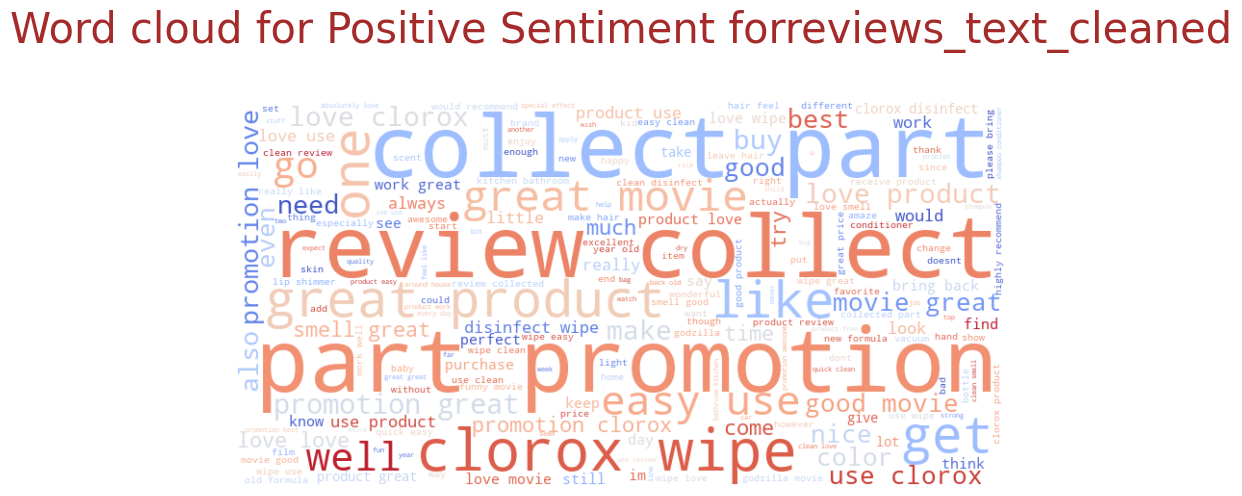

In [256]:
generate_wordcloud(df_clean, "reviews_text_cleaned", 1)

### Negative Reviews most common

In [257]:
print(negative_vocabulary_reviews_40)

[('use', 1560), ('product', 1350), ('review', 899), ('part', 843), ('movie', 829), ('promotion', 801), ('collect', 749), ('wipe', 712), ('like', 710), ('love', 570), ('clorox', 562), ('great', 534), ('get', 482), ('formula', 480), ('one', 456), ('new', 445), ('back', 414), ('hair', 407), ('year', 396), ('old', 376), ('go', 372), ('work', 369), ('buy', 363), ('smell', 362), ('make', 360), ('good', 357), ('clean', 349), ('time', 347), ('bad', 326), ('gel', 314), ('would', 304), ('well', 277), ('bring', 274), ('change', 265), ('please', 234), ('find', 233), ('dont', 228), ('keep', 228), ('godzilla', 228), ('always', 225)]


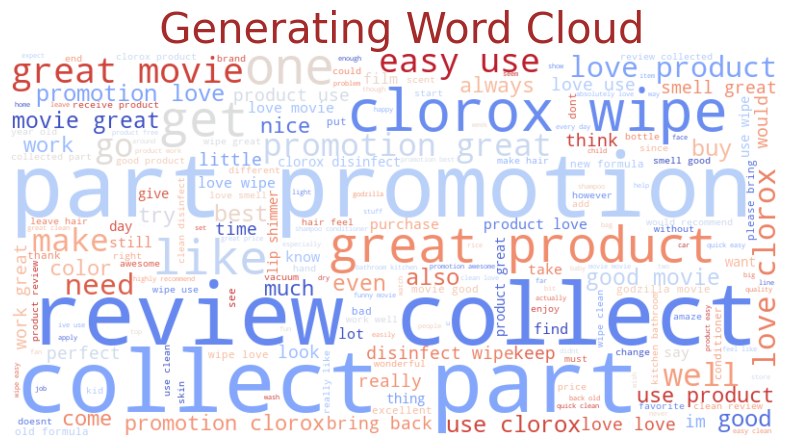

In [258]:
generate_wordcloud(df_clean, "reviews_text_cleaned", 0)

In [259]:
# function to collect the n-gram frequency of words
def get_top_n_ngram(corpus, n_gram_range, n=None):
    vec = CountVectorizer(
        ngram_range=(n_gram_range, n_gram_range), stop_words="english"
    )
    bag_of_words = vec.fit_transform(corpus)

    # print(bag_of_words)
    sum_words = bag_of_words.sum(axis=0)
    # print("--1", sum_words)
    # for word, idx in vec.vocabulary_.items():
    #     print(word)
    #     print(idx)
    #     break
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # print("-31",words_freq)
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

In [260]:
# Print the top 10 words in the bigram frequency
common_words = get_top_n_ngram(pos_reviews["reviews_text_cleaned"], 2, 10)
pd.DataFrame(common_words)

,0,1
0,review collect,7519
1,collect promotion,7519
2,clorox wipe,2574
3,great product,1899
4,great movie,1701
5,easy use,1545
6,love clorox,1172
7,love product,1121
8,good movie,980
9,use clorox,947


NameError: name 'common_words' is not defined

In [261]:
# Print the top 10 words in the bigram frequency
common_words = get_top_n_ngram(neg_reviews["reviews_text_cleaned"], 2, 10)
pd.DataFrame(common_words)

,0,1
0,review collect,747
1,collect promotion,747
2,clorox wipe,259
3,use product,177
4,old formula,172
5,new formula,163
6,use clorox,152
7,bring old,116
8,great product,111
9,resident evil,102


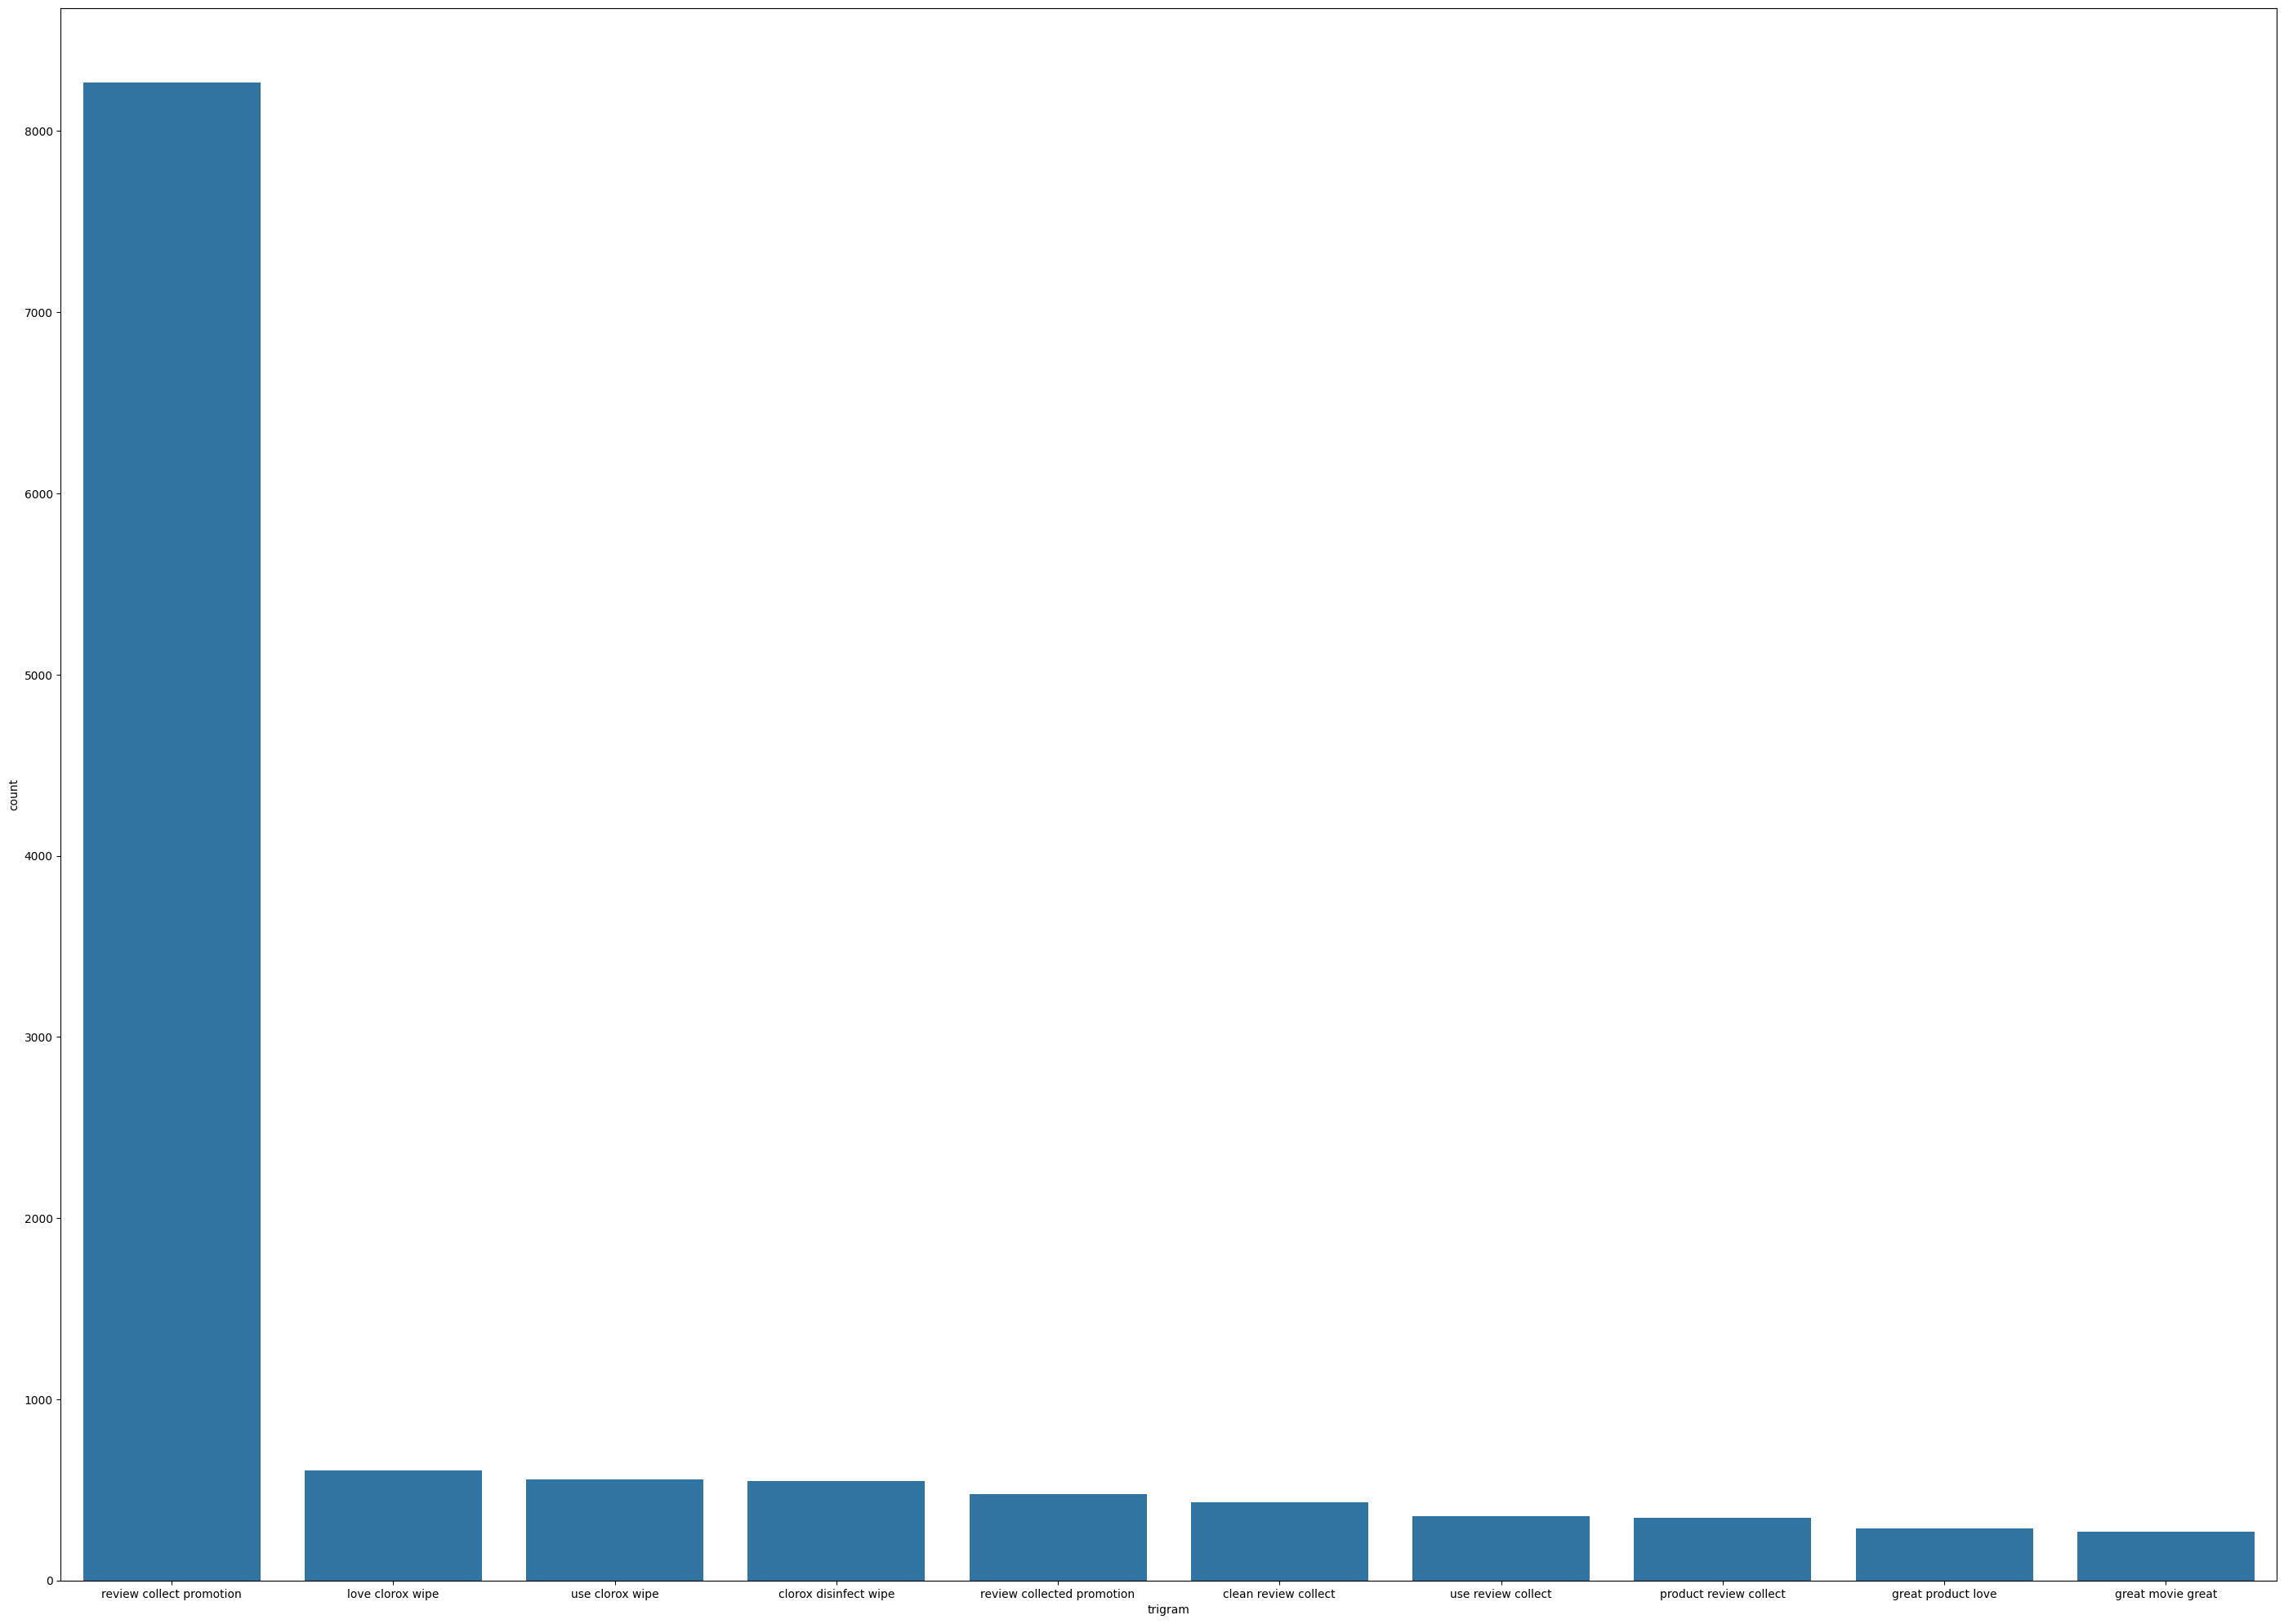

In [262]:
# logic to find the top 10 trigram frequency among the reviews_text in the cleaned datafram(df_clean).
common_words = get_top_n_ngram(df_clean.reviews_text_cleaned, 3, 10)
df3 = pd.DataFrame(common_words, columns=["trigram", "count"])
plt.figure(figsize=[35, 25])
fig = sns.barplot(x=df3["trigram"], y=df3["count"])

## 3 Feature Extraction


In [263]:
X = df_clean["reviews_text_cleaned"]
y = df_clean["user_sentiment"]
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_clean, random_state=42, test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25
)

In [215]:
tf_idf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=650,
    max_df=0.9,
    min_df=7,
    binary=True,
    ngram_range=(1, 2),
)

In [210]:
# X_tf_idf = tf_idf_vectorizer.fit_transform(X)

In [216]:
X_train_tf_idf = tf_idf_vectorizer.fit_transform(X_train)

In [217]:
X_test_tf_idf = tf_idf_vectorizer.transform(X_test)

In [218]:
pd.DataFrame(
    X_train_tf_idf.toarray(), columns=tf_idf_vectorizer.get_feature_names_out()
)

,able,absolutely,absolutely love,act,action,action movie,actor,actually,add,age,ago,amaze,amazing,apply,area,ask,available,away,awesome,awesome movie,awesome product,baby,bad,bag,balm,bathroom,bathroom kitchen,beat,beautiful,bee,begin,believe,best,best buy,best product,big,bit,black,bleach,blu,blu ray,bluray,body,bottle,box,boy,brand,break,bring,bring cocoa,bring old,brown,burt,burt bee,buy,canister,car,care,carpet,carry,cast,cd,chair,change,character,cheap,child,chip,classic,classroom,clay,clean,clean bathroom,clean disinfect,clean easy,clean fresh,clean great,clean kitchen,clean love,clean mess,clean product,clean review,clean smell,clean ups,clean use,clean wipe,cleaner,cleaning,cleanup,clear,clorox,clorox disinfect,clorox product,clorox review,clorox wipe,close,cocoa,cold,collect,collect promotion,...,strong,stuff,style,super,sure,surface,surprise,switch,table,taste,tell,terrible,test,testing,testing purpose,texture,thank,thanks,thats,theater,theyre,thing,think,thought,throw,time,toddler,toilet,totally,touch,towel,toy,tried,true,truly,trust,try,tube,turn,tv,type,ups,use,use clean,use clorox,use daily,use everyday,use great,use house,use kitchen,use love,use product,use review,use time,use use,use wipe,use year,usually,vacuum,value,version,wait,walmart,want,wash,wasnt,watch,watch movie,water,way,wear,week,white,wife,windex,wipe,wipe clean,wipe clorox,wipe convenient,wipe easy,wipe great,wipe love,wipe make,wipe review,wipe use,wish,wonder,wonderful,wont,work,work great,worry,worth,wouldnt,wrong,year,year old,yes,young,youre
0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.14,0.14,...,0.0,0.00,0.0,0.0,0.0,0.29,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.26,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.18,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.21,0.0,0.0,0.00,0.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.29,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.17,0.0,0.0,0.0,0.21,0.0,0.0,0.0,0.14,0.14,...,0.0,0.00,0.0,0.0,0.0,0.29,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.34,0.00,0.0,0.0,0.00,0.0,0.0,0.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.3,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.16,0.32,0.0,0.0,0.0,0.0,0.00,0.0

### Handling Class Imbalance

In [219]:
smote = SMOTE(random_state=42)

In [220]:
help(smote)

Help on SMOTE in module imblearn.over_sampling._smote.base object:

class SMOTE(BaseSMOTE)
 |  SMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5)
 |
 |  Class to perform over-sampling using SMOTE.
 |
 |  This object is an implementation of SMOTE - Synthetic Minority
 |  Over-sampling Technique as presented in [1]_.
 |
 |  Read more in the :ref:`User Guide <smote_adasyn>`.
 |
 |  Parameters
 |  ----------
 |  sampling_strategy : float, str, dict or callable, default='auto'
 |      Sampling information to resample the data set.
 |
 |      - When ``float``, it corresponds to the desired ratio of the number of
 |        samples in the minority class over the number of samples in the
 |        majority class after resampling. Therefore, the ratio is expressed as
 |        :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
 |        number of samples in the minority class after resampling and
 |        :math:`N_{M}` is the number of samples in the majority cla

In [223]:
X_train_scaled, y_train_scaled = smote.fit_resample(X_train_tf_idf, y_train)

In [226]:
X_train_scaled.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(39868, 650))

Class Imbalance after scaling: Counter({1: 19934, 0: 19934})


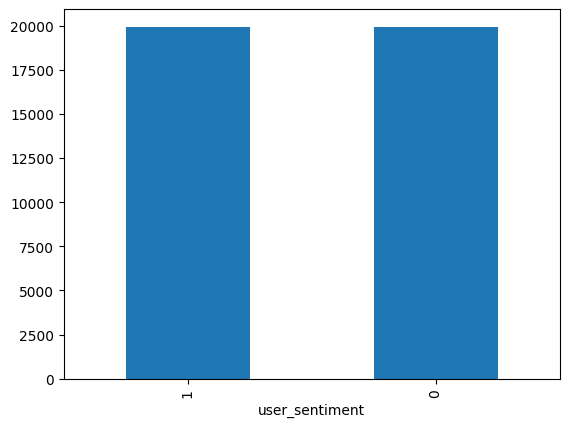

In [224]:
print(f"Class Imbalance after scaling: {Counter(y_train_scaled)}")
y_train_scaled.value_counts().plot.bar()
plt.show()

## 4 Model Building


In [23]:
from sklearn import metrics


class ModelBuilder:
    def __init__(self, model, x_train, x_test, y_train, y_test):
        self.model = model
        self.x_train = x_train
        self.x_test = x_test
        self.y_train = y_train
        self.y_test = y_test

    def train_model(self):
        self.model.fit(self.x_train, self.y_train)
        return self.model.predict(self.x_test)

    def evaluate_model(self, y_pred_class):
        print("\n")
        print("*" * 30)
        self.result_metrics = self.evaluate_metrics(y_pred_class)
        print("*" * 30)
        print("\n")

        self.classification_report(y_pred_class)
        print("*" * 30)
        print("\n")
        # self.confusion_matrix(y_pred_class)

        print("*" * 30)
        print("\n")

        metrics.RocCurveDisplay.from_estimator(self.model, self.x_test, self.y_test)

        return self.result_metrics

    def evaluate_metrics(self, y_pred_class):
        result_metrics = []
        accuracy = metrics.accuracy_score(self.y_test, y_pred_class)
        precision = metrics.precision_score(self.y_test, y_pred_class)
        recall = metrics.recall_score(self.y_test, y_pred_class)
        f1score = metrics.f1_score(self.y_test, y_pred_class)
        y_pred_prob = self.model.predict_proba(self.x_test)[:, 1]
        roc_auc = metrics.roc_auc_score(self.y_test, y_pred_prob)
        tn, fp, fn, tp = confusion_matrix(self.y_test, y_pred_class).ravel()

        sensitivity = np.round(tp / (tp + fn), 2)
        specificity = np.round(tn / (tn + fp), 2)
        confusion = confusion_matrix(self.y_test, y_pred_class)
        tp = confusion[1, 1]  # true positive
        tn = confusion[0, 0]  # true negatives
        fp = confusion[0, 1]  # false positives
        fn = confusion[1, 0]  # false negatives
        print("Sensitivity New", tp / float(tp + fn))
        print(f"Specifity New: {tn / float(tn + fp)}")
        print(f"Sensitivity : {sensitivity * 100:.1f}%")

        print(f"Specificity : {specificity * 100:.1f}%")
        print(f"Accuracy is : {accuracy * 100:.1f}%")
        print(f"Precision is : {precision * 100:.1f}%")
        print(f"Recall is : {recall * 100:.1f}%")
        print(f"F1 Score is : {f1score * 100:.1f}%")
        print(f"Roc-Auc Score is:{roc_auc * 100:.1f}%")

        result_metrics.append(accuracy)
        result_metrics.append(precision)
        result_metrics.append(recall)
        result_metrics.append(f1score)
        result_metrics.append(roc_auc)
        result_metrics.append(sensitivity)
        result_metrics.append(specificity)
        return result_metrics

    def classification_report(self, y_pred_class):
        print(metrics.classification_report(self.y_test, y_pred_class))

### 1. Logistic Regression

In [24]:
# todo replace GridsearchCV with RFECV
lr = LogisticRegression(
    random_state=42, max_iter=1000, solver="liblinear", class_weight="balanced"
)
log_reg_model = ModelBuilder(lr, X_train_scaled, X_test_tf_idf, y_train_scaled, y_test)

NameError: name 'X_train_scaled' is not defined

In [291]:
from sklearn.model_selection import GridSearchCV

# todo replace GridsearchCV with RFECV
lr = LogisticRegression(
    random_state=42, max_iter=1000, solver="liblinear", class_weight="balanced"
)
log_reg_model = ModelBuilder(lr, X_train_scaled, X_test_tf_idf, y_train_scaled, y_test)



******************************
Sensitivity : 89.0%
Specificity : 69.0%
Accuracy is : 86.3%
Precision is : 95.6%
Recall is : 88.6%
F1 Score is : 92.0%
Roc-Auc Score is:89.3%
******************************


              precision    recall  f1-score   support

           0       0.44      0.69      0.54       869
           1       0.96      0.89      0.92      6604

    accuracy                           0.86      7473
   macro avg       0.70      0.79      0.73      7473
weighted avg       0.90      0.86      0.88      7473

******************************


******************************




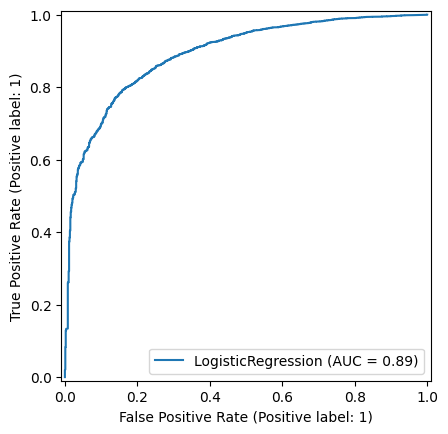

In [292]:
y_pred_class = log_reg_model.train_model()
lr_metrics = log_reg_model.evaluate_model(y_pred_class)

### 2. Random Forest

In [293]:
random_forest_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=10, oob_score=True
)

In [294]:
params = {
    "max_depth": [2, 3, 5, 10, 20],
    "min_samples_leaf": [2, 5, 10, 15, 20, 50],
    "n_estimators": [5, 10, 25, 50, 100],
}

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="f1",
)

In [295]:
grid_search.fit(X_train_scaled, y_train_scaled)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [297]:
rf_best = grid_search.best_estimator_
rf_modelbuilder = ModelBuilder(
    rf_best, X_train_scaled, X_test_tf_idf, y_train_scaled, y_test
)



******************************
Sensitivity : 88.0%
Specificity : 60.0%
Accuracy is : 84.8%
Precision is : 94.3%
Recall is : 88.1%
F1 Score is : 91.1%
Roc-Auc Score is:84.9%
******************************


              precision    recall  f1-score   support

           0       0.40      0.60      0.48       869
           1       0.94      0.88      0.91      6604

    accuracy                           0.85      7473
   macro avg       0.67      0.74      0.69      7473
weighted avg       0.88      0.85      0.86      7473

******************************


******************************




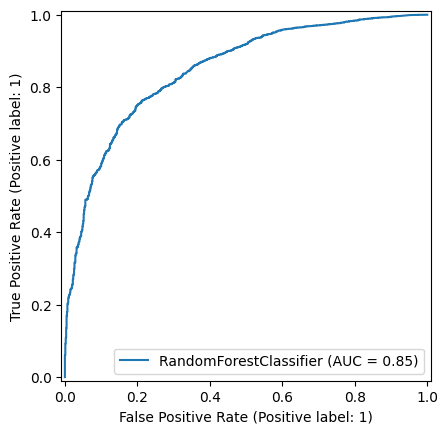

In [298]:
y_pred_class = rf_modebuilder.train_model()
rf_metrics = rf_modelbuilder.evaluate_model(y_pred_class)

### 3. XGBOOST

In [ ]:
# todo
# timators = [10, 15, 20, 25, 30]
# max_features = ["auto", "sqrt"]
# max_depth = [4, 5, 6]
# max_depth.append(
#     None
# )  # If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
# min_samples_split = [2, 5, 10]
# min_samples_leaf = [1, 2, 4]
#
# random_grid = {
#     "n_estimators": n_estimators,
#     "max_features": max_features,
#     "max_depth": max_depth,
#     "min_samples_split": min_samples_split,
#     "min_samples_leaf": min_samples_leaf,
# }
#
# xgb = xgb.XGBClassifier(n_jobs=-1)
#
# xgb_final = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=random_grid,
#     n_iter=5,
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1,
# )
#

In [299]:
import xgboost as xgb

# todo
params1 = {
    "n_estimators": [100, 200, 500, 750],  # no of tres
    "Learning_rate": [0.01, 0.02, 0.05, 0.1, 0.25],
    "min child weight": [1, 5, 7, 10],
    "gamma": [0.1, 0.5, 1, 1.5, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.01],
    "max_depth": [3, 4, 5, 10, 12],
}

folds = 5
param_comb = 800
# random_search = RandomizedSearchCV(xgb_cfl, param_distributions=params, n_iter=param_comb, scoring='f1', n_jobs=-1, cv=5, verbose=3, random_state=42)
# xgb_cfl = xgb.XGBClassifier(n_jobs = -1,objective = 'binary:logistic')

xgclf = xgb.XGBClassifier(
    learning_rate=0.15, max_depth=10, random_state=42
)  # based on the tuned parameters
xg_modelbuilder = ModelBuilder(
    xgclf, X_train_scaled, X_test_tf_idf, y_train_scaled, y_test
)



******************************
Sensitivity : 92.0%
Specificity : 56.0%
Accuracy is : 88.0%
Precision is : 94.1%
Recall is : 92.3%
F1 Score is : 93.2%
Roc-Auc Score is:88.4%
******************************


              precision    recall  f1-score   support

           0       0.49      0.56      0.52       869
           1       0.94      0.92      0.93      6604

    accuracy                           0.88      7473
   macro avg       0.71      0.74      0.73      7473
weighted avg       0.89      0.88      0.88      7473

******************************


******************************




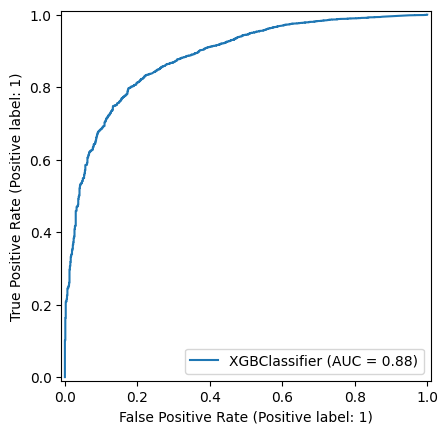

In [300]:
y_pred_class = xg_modelbuilder.train_model()
xg_metrics = xg_modelbuilder.evaluate_model(y_pred_class)

### 4. Naive Bayes

In [301]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB(alpha=1.0)
mnb_modelbuilder = ModelBuilder(
    mnb, X_train_scaled, X_test_tf_idf, y_train_scaled, y_test
)



******************************
Sensitivity : 81.0%
Specificity : 71.0%
Accuracy is : 79.4%
Precision is : 95.4%
Recall is : 80.5%
F1 Score is : 87.3%
Roc-Auc Score is:83.1%
******************************


              precision    recall  f1-score   support

           0       0.32      0.71      0.44       869
           1       0.95      0.81      0.87      6604

    accuracy                           0.79      7473
   macro avg       0.64      0.76      0.66      7473
weighted avg       0.88      0.79      0.82      7473

******************************


******************************




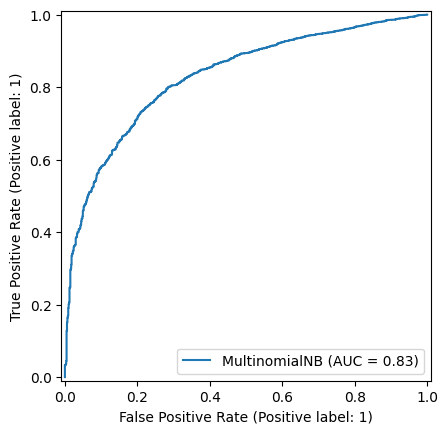

In [302]:
y_test_pred_bnb = mnb_modelbuilder.train_model()

nb_metrics = mnb_modelbuilder.evaluate_model(y_test_pred_bnb)

#### Model Inference

In [303]:
metrics_table = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1Score",
        "Auc Score",
        "Sensitivity",
        "Specificity",
    ],
    "Logistic Regression": lr_metrics,
    "Naive Bayes": nb_metrics,
    "Random Forest": rf_metrics,
    "XG Boost": xg_metrics,
}

df_metrics = pd.DataFrame(
    metrics_table,
    columns=[
        "Metric",
        "Logistic Regression",
        "Naive Bayes",
        "Random Forrest",
        "XG Boost",
    ],
)

df_metrics

,Metric,Logistic Regression,Naive Bayes,Random Forrest,XG Boost
0,Accuracy,0.86,0.79,0.85,0.88
1,Precision,0.96,0.95,0.94,0.94
2,Recall,0.89,0.81,0.88,0.92
3,F1Score,0.92,0.87,0.91,0.93
4,Auc Score,0.89,0.83,0.85,0.88
5,Sensitivity,0.89,0.81,0.88,0.92
6,Specificity,0.69,0.71,0.60,0.56


In [304]:
df_metrics.to_csv("output.csv")

#### Saving the model

In [305]:
import pickle


def save_object(obj, filename):
    os.makedirs("pickle", exist_ok=True)
    filename = "pickle/" + filename + ".pkl"
    pickle.dump(obj, open(filename, "wb"))

In [306]:
def save_obj(file):
    name = "pickle" + file + ".pkl"

    os.makedirs("pickle", exist_ok=True)

    with open(name, "wb") as f:
        return f.write(pickle.dumps(f))


def load_obj(file):
    with open(file, "rb") as f:
        obj = f.read()
        return pickle.loads(obj)

In [307]:
save_object(xgclf, "sentiment-classification-xg-boost-model")

In [95]:
save_object(rf_best, "sentiment-classification-random-forest")

In [308]:
save_object(log_reg_model, "sentime-classification-logreg")

In [309]:
save_object(tf_idf_vectorizer, "tfidf-vectorizer")

In [310]:
save_object(df_clean, "cleaned-data")

In [311]:
save_object(df_reviews, "df_review")

In [312]:
df_clean.to_csv("df_clean_sentiment_april24.csv", index=False)

# 5. Building the Recommendation System

In [313]:
## Loading from checkpoint
df_sentiment = pd.read_csv("df_clean_sentiment_april24.csv")

In [314]:
df_sentiment1 = df_sentiment.copy()

In [315]:
df_sentiment = df_sentiment[["reviews_username", "name", "reviews_rating"]]

In [316]:
df_sentiment.rename(
    {
        "reviews_username": "username",
        "name": "product_name",
        "reviews_rating": "rating",
    },
    axis=1,
    inplace=True,
)

In [19]:
df_sentiment[:3]

,username,product_name,rating
0,joshua,Pink Friday: Roman Reloaded Re-Up (w/dvd),5
1,dorothy w,Lundberg Organic Cinnamon Toast Rice Cakes,5
2,dorothy w,Lundberg Organic Cinnamon Toast Rice Cakes,5


### Dividing the dataset into train and test

In [20]:
df_sentiment_train, df_sentiment_test = train_test_split(
    df_sentiment, test_size=0.3, random_state=42
)

In [21]:
train = df_sentiment_train.copy()
test = df_sentiment_test.copy()

### Creating dummy train & dummy test dataset
These dataset will be used for prediction
- Dummy train will be used later for prediction of the products which has not been rated by the user. To ignore the products rated by the user, we will mark it as 0 during prediction. The products not rated by user is marked as 1 for prediction in dummy train dataset.

- Dummy test will be used for evaluation. To evaluate, we will only make prediction on the products rated by the user. So, this is marked as 1. This is just opposite of dummy_train.


In [22]:
df_pivot = df_sentiment_train.pivot_table(
    index="username", columns="product_name", values="rating"
).fillna(0)

In [23]:
df_pivot.sample(10)

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [24]:
dummy_train = df_sentiment_train.copy()

In [25]:
dummy_train["rating"] = dummy_train["rating"].apply(lambda x: 0 if x >= 1 else 1)

In [26]:
dummy_train = dummy_train.pivot_table(
    index="username", columns="product_name", values="rating"
).fillna(1)

## User Similarity Matrix


####  Using  Cosine similarity


In [29]:
from sklearn.metrics.pairwise import pairwise_distances

# Creating the User Similarity Matrix using pairwise_distance function.
user_correlation = 1 - pairwise_distances(dummy_train, metric="cosine")

In [30]:
user_correlation[np.isnan(user_correlation)] = 0

In [31]:
user_correlation.shape

(18260, 18260)

In [32]:
# Create a user- matrix.
df_pivot = train.pivot_table(index="username", columns="product_name", values="rating")

In [33]:
df_pivot.sample(10)

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [34]:
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T - mean).T

In [35]:
df_subtracted.sample(10)

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [38]:
from sklearn.metrics.pairwise import pairwise_distances

In [39]:
# Create a user-product matrix.
user_correlation = 1 - pairwise_distances(df_subtracted.fillna(0), metric="cosine")
user_correlation[np.isnan(user_correlation)] = 0
user_correlation[:5]

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 18260))

In [41]:
user_correlation

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(18260, 18260))

## Prediction - User User

Doing the prediction for the users which are positively related with other users, and not the users which are negatively related as we are interested in the users which are more similar to the current users. So, ignoring the correlation for values less than 0.

In [42]:
user_correlation[user_correlation < 0] = 0
user_correlation[:5]

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 18260))

In [44]:
user_predicted_ratings = np.dot(user_correlation, df_pivot.fillna(0))
user_predicted_ratings[:10]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 5.76309081, 0.        , ..., 4.86524412, 0.42640143,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 5.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(10, 252))

In [45]:
user_predicted_ratings.shape

(18260, 252)

Since we are interested only in the products not rated by the user, we will ignore the products rated by the user by making it zero.

In [46]:
user_final_rating = np.multiply(user_predicted_ratings, dummy_train)
user_final_rating.head()

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [152]:
user_final_rating.index

Index(['00dog3', '00sab00', '01impala', '02dakota', '02deuce', '0325home',
       '06stidriver', '08dallas', '09mommy11', '1.11E+24',
       ...
       'zsarah', 'zsazsa', 'zt313', 'zulaa118', 'zuttle', 'zxcsdfd', 'zxjki',
       'zyiah4', 'zzdiane', 'zzz1127'],
      dtype='str', name='username', length=18260)

## Evaluation - User User

Evaluation will we same as you have seen above for the prediction. The only difference being, you will evaluate for the product already rated by the user insead of predicting it for the product not rated by the user.

In [47]:
# Find out the common users of test and train dataset.
common = df_sentiment_test[
    df_sentiment_test["username"].isin(df_sentiment_train.username)
]
common.shape

(2070, 3)

In [48]:
common[:5]

,username,product_name,rating
25011,michelle,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,5
1555,joshua,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),3
17702,becca,"Coty Airspun Face Powder, Translucent Extra Coverage",5
29507,hallee,L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz,4
12085,dianemango,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5


In [38]:
# common[["username", "product_name", "rating"]].to_csv("common.csv", index=False)

In [39]:
# common_backup = common[["username", "product_name", "rating"]]

In [54]:
# convert into the user-product matrix.
common_pivot = common.pivot_table(
    index="username", columns="product_name", values="rating"
)

In [55]:
# Convert the user_correlation matrix into dataframe.
user_correlation_df = pd.DataFrame(user_correlation)

In [56]:
user_correlation_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,...,18160,18161,18162,18163,18164,18165,18166,18167,18168,18169,18170,18171,18172,18173,18174,18175,18176,18177,18178,18179,18180,18181,18182,18183,18184,18185,18186,18187,18188,18189,18190,18191,18192,18193,18194,18195,18196,18197,18198,18199,18200,18201,18202,18203,18204,18205,18206,18207,18208,18209,18210,18211,18212,18213,18214,18215,18216,18217,18218,18219,18220,18221,18222,18223,18224,18225,18226,18227,18228,18229,18230,18231,18232,18233,18234,18235,18236,18237,18238,18239,18240,18241,18242,18243,18244,18245,18246,18247,18248,18249,18250,18251,18252,18253,18254,18255,18256,18257,18258,18259
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [57]:
df_subtracted.head(5)

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [58]:
user_correlation_df["username"] = df_subtracted.index
user_correlation_df.set_index("username", inplace=True)
user_correlation_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,...,18160,18161,18162,18163,18164,18165,18166,18167,18168,18169,18170,18171,18172,18173,18174,18175,18176,18177,18178,18179,18180,18181,18182,18183,18184,18185,18186,18187,18188,18189,18190,18191,18192,18193,18194,18195,18196,18197,18198,18199,18200,18201,18202,18203,18204,18205,18206,18207,18208,18209,18210,18211,18212,18213,18214,18215,18216,18217,18218,18219,18220,18221,18222,18223,18224,18225,18226,18227,18228,18229,18230,18231,18232,18233,18234,18235,18236,18237,18238,18239,18240,18241,18242,18243,18244,18245,18246,18247,18248,18249,18250,18251,18252,18253,18254,18255,18256,18257,18258,18259
username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00dog3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00sab00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02dakota,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [59]:
list_name = common.username.tolist()

user_correlation_df.columns = df_subtracted.index.tolist()

user_correlation_df_1 = user_correlation_df[user_correlation_df.index.isin(list_name)]

In [60]:
user_correlation_df_1[:5]

,00dog3,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,10ten,11677j,1234,1234567,1234asdf,123cat123,123numbers,123rs,123soccermom,123too,127726,12cass12,12gage,132457,13dani,13ld,13ram,13thfaerie,143st,148maine,1515,15425shopper,1616,170361eggs,1753,17roses,18612,1863philly,1943,1968bear,1979edes,1992firebirdgirl,19bubba67,1awesome1,1boomer,1cadet,1clean1,1cleaner,1derpet1,1disappoint,1friendlycat,1gamer,1gussy,1happymom,1healthytot,1izzy1,1jc1,1jodie,1kindword,1nikki31t,1officegal,1okc2thunder3up4,1olaygal,1scooby1,1sonny,1stcavdivision,1stlady,1sttimemama,1sungirl,1texasmom,1tomg,1vgarcia,1witch,2011mom2b,2011pink2011,2013bestbuyer,2016,2016home,2016parker10,2062351337,210tundra,2175046722,21honey,21please,232323,23jen,24hrstoneroses,2532674594,25happyshopper,262jennifer,2827,28green,295259,2busy4u,2choclabs,2clean4me,2ds4es14,2esinapod,2forhokies,...,yoshi,youjon,youknowit459,youlooksolovely,younggrannie62,yourmom,ypryor,ythelastman89,yttric,yucky111,yulkakapulka,yummy,yumyum,yunji,yvonne,yzkgsx,z12345,z33pisces,zabdelra,zach,zacharymcneill,zacharysaunt,zachsmom,zacroxs,zaibo,zak,zakkwylde29,zakkzakk,zamanda,zanarkandruinsx2,zanzan73,zapaduh,zapman,zara0215,zara07,zarah,zarrahsmommy,zaskar,zaza,zburt5,zchandyman,zebras,zebrastrong,zeek,zeek09,zeeleader,zegan,zelyas,zenmon,zer0zer0agent,zeramm,zero,zeroonec,zhio,zhynellebb,zibber23,ziggy,zillanator,zimmeyb,zina911,zink,zinnian,zipflip,zipp,zipper,zipperdoo,zippy,zitro,zittles,zman69,zmom,znxfyt,zodness,zoe1988,zoeellasca,zoeyny,zokhid,zombiedad80,zombiegirl22,zombiejess,zombiekiller,zone,zoney86,zooey_57,zookeeper,zoomin76,zoso60,zout22389,zowie,zpalma,zsarah,zsazsa,zt313,zulaa118,zuttle,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
username,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
143st,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0

In [61]:
# user_correlation_df.columns

In [62]:
user_correlation_df_1.info()

<class 'pandas.DataFrame'>
Index: 1716 entries, 1234 to zmom
Columns: 18260 entries, 00dog3 to zzz1127
dtypes: float64(18260)
memory usage: 239.1+ MB


In [63]:
user_correlation_df_2 = user_correlation_df_1.T[
    user_correlation_df_1.T.index.isin(list_name)
]

In [64]:
user_correlation_df_2[:10]

username,1234,1234567,143st,1943,23jen,37f5p,4cloroxl,4djs,aac06002,aaron,abbey,abc,abcssds,abigail,abret,ace24,acg1,aclass,adam,adamsmom,adizzione,adma2,adriana,adriana9999,adrienne,ael26,afwifey2003,agmt,ah78,aimee,aj1135,aj2012,ajay,ajface24,ajune,akesler19,alena125,alex,alexis,alice,alisonr,allan6048,allie,allie123,allison33,ally,ally1989,alredhouse,alta,alvin,aly16,amanda,amazing,amber,amber0528,amerbamer,amishmom,amsmes26,amy1,amy77,amyrn,anabanana2112,anas79,anatnas4,andi,andie,andiejo,andrea,andreafl,andrew,andy,angel,angela,angelbabee1965,angie,angie0104,angie447,angiesmessykids,anita,ann222,anna,annalou75,annie,anonymous 1,anthony,anyab,april,arlene,arlingtondonna,arob,aros,as123,ash23,ash4,ash82085,ashley,ashley000,ashleylysette,ashsmash,atacjj,...,tjab,tjzmom,tmc1,tmoxvan,toby,todd,toddster7,tomi,tominator,tommty41,toni,tony,tony1,tooney38,toot34,tootsie23,topaz0502,torrie,toshcal,totesaddicted,tracelyn28,tracie,trav,trcvngrn,treader,treese,trina,trish,trisha,trix,truth,tstarr,ttdebbi,ttop,turtle,turtleboy,turtlesgirl7,tw350z,twebb,twin,tycr,typist,unicorn351,unnamed,val,val214,valery,vanessavast,vc13,vccaan,viccckybooo,vicki,vickie,victor,victoria29,viking80,vivi37,vivian,viviln,vlo910,vyph,vypkf0,wally,watson28,wendy,wendy2245,wendy59,wernigcourtney,weston t,whome,wildchild23,wildman,willy,wimbly,wind,windowkitty,wise,wiseman378,wizard,wolfie,wolvarine,wolverine,wonderwoman,woottos,wownostreaks,wowwie,wren113,wvshopaholic,xavier,xmom,yazzmiin,yellow,yeyo,yorkielvr,yucky111,yummy,zebras,zipper,zippy,zmom
1234,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234567,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
143st,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1943,0.0,0.0,0

In [65]:
user_correlation_df_3 = user_correlation_df_2.T

In [66]:
print(user_correlation_df_3.head())

          1234  1234567  143st  1943  23jen  37f5p  4cloroxl  4djs  aac06002  \
username                                                                       
1234       1.0      0.0    0.0   0.0    0.0    0.0       0.0   0.0       0.0   
1234567    0.0      1.0    0.0   0.0    0.0    0.0       0.0   0.0       0.0   
143st      0.0      0.0    1.0   0.0    0.0    0.0       0.0   0.0       0.0   
1943       0.0      0.0    0.0   1.0    0.0    0.0       0.0   0.0       0.0   
23jen      0.0      0.0    0.0   0.0    1.0    0.0       0.0   0.0       0.0   

          aaron  abbey  abc  abcssds  abigail  abret  ace24  acg1  aclass  \
username                                                                    
1234        0.0    0.0  0.0      0.0      0.0    0.0    0.0   0.0     0.0   
1234567     0.0    0.0  0.0      0.0      0.0    0.0    0.0   0.0     0.0   
143st       0.0    0.0  0.0      0.0      0.0    0.0    0.0   0.0     0.0   
1943        0.0    0.0  0.0      0.0      0.0    0.0  

In [67]:
user_correlation_df_3.shape

(1716, 1716)

In [68]:
user_correlation_df_3[user_correlation_df_3 < 0] = 0

common_user_predicted_ratings = np.dot(
    user_correlation_df_3, common_user_based_matrix.fillna(0)
)
common_user_predicted_ratings[:4]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 5., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 5., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
   

In [69]:
dummy_test = common.copy()

dummy_test["rating"] = dummy_test["rating"].apply(lambda x: 1 if x >= 1 else 0)

dummy_test = dummy_test.pivot_table(
    index="username", columns="product_name", values="rating"
).fillna(0)

In [70]:
dummy_test.shape

(1716, 125)

In [71]:
common_user_predicted_ratings = np.multiply(common_user_predicted_ratings, dummy_test)

In [72]:
common_user_predicted_ratings[:10].T

username,1234,1234567,143st,1943,23jen,37f5p,4cloroxl,4djs,aac06002,aaron
product_name,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100:Complete First Season (blu-Ray),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alex Cross (dvdvideo),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"All,bran Complete Wheat Flakes, 18 Oz.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
"Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Windex Original Glass Cleaner Refill 67.6oz (2 Liter),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Calculating the RMSE for only the products rated by user. For RMSE, normalising the rating to (1,5) range.

In [73]:
from sklearn.preprocessing import MinMaxScaler

X = common_user_predicted_ratings.copy()
X = X[X > 0]

scaler = MinMaxScaler(feature_range=(1, 5))
print(scaler.fit(X))
y = scaler.transform(X)

print(y)

MinMaxScaler(feature_range=(1, 5))
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [74]:
X[:5]

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz","Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter","BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin",Cantu Coconut Milk Shine Hold Mist - 8oz,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,CeraVe SA Renewing Cream,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,"Colorganics Lipstick, Cayenne","Coty Airspun Face Powder, Translucent Extra Coverage",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Equals (blu-Ray),Feit 60-Watt A19 Gu24 Base Led Light Bulb - Soft White,"Finish Quantum Dishwasher Detergent, Lemon Sparkle Scent, 45 Count",Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,Happy Tot Apple and Butternut Squash,Hawaiian Punch Berry Limeade Blast Juice,Head & Shoulders Classic Clean Conditioner,Head & Shoulders Dandruff Shampoo Ocean Lift 2 In 1,Hollywood Beauty Olive Cholesterol,Hoover174 Platinum Collection153 Lightweight Bagged Upright Vacuum With Canister - Uh30010com,"Hormel Chili, No Beans",J.a. Henckels International 4-Pc Everedge Plus Steak Knife Set,Jason Aldean - They Don't Know,"Johnson's Baby Bubble Bath and Wash, 15oz",Jolly Time Select Premium Yellow Pop Corn,"Just For Men Touch Of Gray Gray Hair Treatment, Black T-55",K-Y Love Sensuality Pleasure Gel,Kind Dark Chocolate Chunk Gluten Free Granola Bars - 5 Count,Kind Nut Delight Bar,L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz,L'oreal Paris Advanced Hairstyle TXT IT Hyper-Fix Putty,Leslie Sansone:Belly Blasting Walk (dvd),"Lundberg Wehani Rice, 25lb",Lynk Professional174 Pull Out Cutting Board Bakeware Sliding Cabinet Organizer,"Lysol Concentrate Deodorizing Cleaner, Original Scent",Meguiar's Deep Crystal Car Wash 64-Oz.,Meguiar's Ultimate Quik Detailer 22-Oz.,Mike Dave Need Wedding Dates (dvd + Digital),Mill Creek Aloe Vera & Paba Lotion,Moom Express Pre Waxed Strips For Face & Bikini,Mrs. Meyer's Lemon Verbena Surface Scrub,Mrs. Meyer's174 Lemon Verbena Laundry Scent Booster - 18oz,My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital),Nature's Path Chunky Chocolate Peanut Chewy Granola Bars,Nature's Path Flax Plus Maple Pecan Crunch Cereal,Naturtint Nutrideep Multiplier Protective Cream,"Newman's Own Organics Licorice Twist, Black 5oz",Nexxus Exxtra Gel Style Creation Sculptor,"Ogx Conditioner, Hydrating Teatree Mint",Olay Regenerist Deep Hydration Regenerating Cream,Orajel Maximum Strength Toothache Pain Relief Liquid,Pantene Pro-V Expert Collection Age Defy Conditioner,"Pendaflex174 Divide It Up File Folder, Multi Section, Let

In [75]:
common_ = common.pivot_table(index="username", columns="product_name", values="rating")

In [76]:
# Finding total non-NaN value
total_non_nan = np.count_nonzero(~np.isnan(y))

In [77]:
rmse = (np.sum(np.sum((common_ - y) ** 2)) / total_non_nan) ** 0.5
print(rmse)

2.210573628233655


## Using Item similarity

### Item Based Similarity

Taking the transpose of the rating matrix to normalize the rating around the mean for different product ID. In the user based similarity, we had taken mean for each user instead of each product.

In [78]:
df_pivot = df_sentiment_train.pivot_table(
    index="username", columns="product_name", values="rating"
).T

df_pivot.head()

username,00dog3,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,10ten,11677j,1234,1234567,1234asdf,123cat123,123numbers,123rs,123soccermom,123too,127726,12cass12,12gage,132457,13dani,13ld,13ram,13thfaerie,143st,148maine,1515,15425shopper,1616,170361eggs,1753,17roses,18612,1863philly,1943,1968bear,1979edes,1992firebirdgirl,19bubba67,1awesome1,1boomer,1cadet,1clean1,1cleaner,1derpet1,1disappoint,1friendlycat,1gamer,1gussy,1happymom,1healthytot,1izzy1,1jc1,1jodie,1kindword,1nikki31t,1officegal,1okc2thunder3up4,1olaygal,1scooby1,1sonny,1stcavdivision,1stlady,1sttimemama,1sungirl,1texasmom,1tomg,1vgarcia,1witch,2011mom2b,2011pink2011,2013bestbuyer,2016,2016home,2016parker10,2062351337,210tundra,2175046722,21honey,21please,232323,23jen,24hrstoneroses,2532674594,25happyshopper,262jennifer,2827,28green,295259,2busy4u,2choclabs,2clean4me,2ds4es14,2esinapod,2forhokies,...,yoshi,youjon,youknowit459,youlooksolovely,younggrannie62,yourmom,ypryor,ythelastman89,yttric,yucky111,yulkakapulka,yummy,yumyum,yunji,yvonne,yzkgsx,z12345,z33pisces,zabdelra,zach,zacharymcneill,zacharysaunt,zachsmom,zacroxs,zaibo,zak,zakkwylde29,zakkzakk,zamanda,zanarkandruinsx2,zanzan73,zapaduh,zapman,zara0215,zara07,zarah,zarrahsmommy,zaskar,zaza,zburt5,zchandyman,zebras,zebrastrong,zeek,zeek09,zeeleader,zegan,zelyas,zenmon,zer0zer0agent,zeramm,zero,zeroonec,zhio,zhynellebb,zibber23,ziggy,zillanator,zimmeyb,zina911,zink,zinnian,zipflip,zipp,zipper,zipperdoo,zippy,zitro,zittles,zman69,zmom,znxfyt,zodness,zoe1988,zoeellasca,zoeyny,zokhid,zombiedad80,zombiegirl22,zombiejess,zombiekiller,zone,zoney86,zooey_57,zookeeper,zoomin76,zoso60,zout22389,zowie,zpalma,zsarah,zsazsa,zt313,zulaa118,zuttle,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100:Complete First Season (blu-Ray),NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Normalising the product rating for each product for using the Adujsted Cosine

In [79]:
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T - mean).T

In [80]:
df_subtracted.sample(10)

username,00dog3,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,10ten,11677j,1234,1234567,1234asdf,123cat123,123numbers,123rs,123soccermom,123too,127726,12cass12,12gage,132457,13dani,13ld,13ram,13thfaerie,143st,148maine,1515,15425shopper,1616,170361eggs,1753,17roses,18612,1863philly,1943,1968bear,1979edes,1992firebirdgirl,19bubba67,1awesome1,1boomer,1cadet,1clean1,1cleaner,1derpet1,1disappoint,1friendlycat,1gamer,1gussy,1happymom,1healthytot,1izzy1,1jc1,1jodie,1kindword,1nikki31t,1officegal,1okc2thunder3up4,1olaygal,1scooby1,1sonny,1stcavdivision,1stlady,1sttimemama,1sungirl,1texasmom,1tomg,1vgarcia,1witch,2011mom2b,2011pink2011,2013bestbuyer,2016,2016home,2016parker10,2062351337,210tundra,2175046722,21honey,21please,232323,23jen,24hrstoneroses,2532674594,25happyshopper,262jennifer,2827,28green,295259,2busy4u,2choclabs,2clean4me,2ds4es14,2esinapod,2forhokies,...,yoshi,youjon,youknowit459,youlooksolovely,younggrannie62,yourmom,ypryor,ythelastman89,yttric,yucky111,yulkakapulka,yummy,yumyum,yunji,yvonne,yzkgsx,z12345,z33pisces,zabdelra,zach,zacharymcneill,zacharysaunt,zachsmom,zacroxs,zaibo,zak,zakkwylde29,zakkzakk,zamanda,zanarkandruinsx2,zanzan73,zapaduh,zapman,zara0215,zara07,zarah,zarrahsmommy,zaskar,zaza,zburt5,zchandyman,zebras,zebrastrong,zeek,zeek09,zeeleader,zegan,zelyas,zenmon,zer0zer0agent,zeramm,zero,zeroonec,zhio,zhynellebb,zibber23,ziggy,zillanator,zimmeyb,zina911,zink,zinnian,zipflip,zipp,zipper,zipperdoo,zippy,zitro,zittles,zman69,zmom,znxfyt,zodness,zoe1988,zoeellasca,zoeyny,zokhid,zombiedad80,zombiegirl22,zombiejess,zombiekiller,zone,zoney86,zooey_57,zookeeper,zoomin76,zoso60,zout22389,zowie,zpalma,zsarah,zsazsa,zt313,zulaa118,zuttle,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Charcoal Stone Toothbrush Holder Gray,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tramontina Ceramica 10 Piece Cookware Set - Red,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Newman's Own Organics Licorice Twist, Black 5oz",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Finding the cosine similarity using pairwise distances approach

In [81]:
df_subtracted.fillna(0)

username,00dog3,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,10ten,11677j,1234,1234567,1234asdf,123cat123,123numbers,123rs,123soccermom,123too,127726,12cass12,12gage,132457,13dani,13ld,13ram,13thfaerie,143st,148maine,1515,15425shopper,1616,170361eggs,1753,17roses,18612,1863philly,1943,1968bear,1979edes,1992firebirdgirl,19bubba67,1awesome1,1boomer,1cadet,1clean1,1cleaner,1derpet1,1disappoint,1friendlycat,1gamer,1gussy,1happymom,1healthytot,1izzy1,1jc1,1jodie,1kindword,1nikki31t,1officegal,1okc2thunder3up4,1olaygal,1scooby1,1sonny,1stcavdivision,1stlady,1sttimemama,1sungirl,1texasmom,1tomg,1vgarcia,1witch,2011mom2b,2011pink2011,2013bestbuyer,2016,2016home,2016parker10,2062351337,210tundra,2175046722,21honey,21please,232323,23jen,24hrstoneroses,2532674594,25happyshopper,262jennifer,2827,28green,295259,2busy4u,2choclabs,2clean4me,2ds4es14,2esinapod,2forhokies,...,yoshi,youjon,youknowit459,youlooksolovely,younggrannie62,yourmom,ypryor,ythelastman89,yttric,yucky111,yulkakapulka,yummy,yumyum,yunji,yvonne,yzkgsx,z12345,z33pisces,zabdelra,zach,zacharymcneill,zacharysaunt,zachsmom,zacroxs,zaibo,zak,zakkwylde29,zakkzakk,zamanda,zanarkandruinsx2,zanzan73,zapaduh,zapman,zara0215,zara07,zarah,zarrahsmommy,zaskar,zaza,zburt5,zchandyman,zebras,zebrastrong,zeek,zeek09,zeeleader,zegan,zelyas,zenmon,zer0zer0agent,zeramm,zero,zeroonec,zhio,zhynellebb,zibber23,ziggy,zillanator,zimmeyb,zina911,zink,zinnian,zipflip,zipp,zipper,zipperdoo,zippy,zitro,zittles,zman69,zmom,znxfyt,zodness,zoe1988,zoeellasca,zoeyny,zokhid,zombiedad80,zombiegirl22,zombiejess,zombiekiller,zone,zoney86,zooey_57,zookeeper,zoomin76,zoso60,zout22389,zowie,zpalma,zsarah,zsazsa,zt313,zulaa118,zuttle,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100:Complete First Season (blu-Ray),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [82]:
# Item Similarity Matrix
item_correlation = 1 - pairwise_distances(df_subtracted.fillna(0), metric="cosine")
item_correlation[np.isnan(item_correlation)] = 0

In [83]:
item_correlation.min(), item_correlation.mean(), item_correlation.max()

(np.float64(-0.2543633311335425),
 np.float64(0.0040099603505854165),
 np.float64(1.0))

Filtering the correlation only for which the value is greater than 0. (Positively correlated)

In [84]:
item_correlation[item_correlation < 0] = 0
item_correlation[:5]

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 252))

## Prediction - Item Item

In [85]:
item_predicted_ratings = np.dot(df_pivot.fillna(0).T, item_correlation)
item_predicted_ratings

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.02367295, 0.        , ..., 0.00441193, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.0032195 ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.00202426, 0.        ,
        0.        ],
       [0.        , 0.03945491, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00161941, 0.        ,
        0.        ]], shape=(18260, 252))

In [86]:
dummy_train.shape

(18260, 252)

### Filtering the rating only for the products not rated by the user for recommendation

In [87]:
item_final_rating = np.multiply(item_predicted_ratings, dummy_train)
item_final_rating.head()

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [88]:
item_final_rating.sample(10)

product_name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan S

In [89]:
item_final_rating.shape

(18260, 252)

In [90]:
item_final_rating.max()

product_name
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest        25.00
100:Complete First Season (blu-Ray)                                  25.39
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black    25.00
2x Ultra Era with Oxi Booster, 50fl oz                               25.00
42 Dual Drop Leaf Table with 2 Madrid Chairs"                        25.00
                                                                     ...  
Weleda Everon Lip Balm                                               25.00
Wilton Black Dots Standard Baking Cups                               25.00
Windex Original Glass Cleaner Refill 67.6oz (2 Liter)                25.64
Yes To Carrots Nourishing Body Wash                                  25.04
Yes To Grapefruit Rejuvenating Body Wash                             25.76
Length: 252, dtype: float64

## Evaluation - Item Item

Evaluation will we same as you have seen above for the prediction. The only difference being, you will evaluate for the product already rated by the user insead of predicting it for the product not rated by the user.

In [91]:
test = df_sentiment_test
test.columns

Index(['username', 'product_name', 'rating'], dtype='str')

In [92]:
common = test[test.product_name.isin(train.product_name)]
common.shape

(8946, 3)

In [93]:
common.head(4)

,username,product_name,rating
25011,michelle,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,5
5114,jack3,The Resident Evil Collection 5 Discs (blu-Ray),5
4254,loriluvsherplatinum,Hoover174 Platinum Collection153 Lightweight Bagged Upright Vacuum With Canister - Uh30010com,5
7779,saramp,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,4


In [94]:
common_item_based_matrix = common.pivot_table(
    index="username", columns="product_name", values="rating"
).T

In [95]:
common_item_based_matrix.shape

(189, 8305)

In [96]:
item_correlation_df = pd.DataFrame(item_correlation)

In [97]:
item_correlation_df[:5]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,...,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.72e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.68e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.13e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.51e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.46e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.54e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [98]:
item_correlation_df["product_name"] = df_subtracted.index
item_correlation_df.set_index("product_name", inplace=True)
item_correlation_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,...,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100:Complete First Season (blu-Ray),0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.72e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.68e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.13e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.51e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.46e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.54e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"2x Ultra Era with Oxi Booster, 50fl oz",0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [99]:
list_name = common.product_name.tolist()

In [100]:
item_correlation_df.columns = df_subtracted.index.tolist()

item_correlation_df_1 = item_correlation_df[item_correlation_df.index.isin(list_name)]

In [101]:
item_correlation_df_1

,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz","42 Dual Drop Leaf Table with 2 Madrid Chairs""",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Ambi Complexion Cleansing Bar,Annie's Homegrown Deluxe Elbows & Four Cheese Sauce,Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz",Avery174 11-1/4 X 9-1/4 Index Maker Extra Wide Label Dividers With 5 Tab - Clear (5 Sets Per Pack),"Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,"Batherapy Natural Mineral Bath Sport Liquid, 16 oz",Baxter Of California Cream Pomade,"Beanitos Bean Chips, Simply Pinto Bean",Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bi-O-kleen Spray & Wipe All Purpose Cleaner,Bilbao Nightstand Gray Oak - South Shore,Bill Glor Gaither - Church In The Wildwood (cd),Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Blue Anchor Design Throw Pillow (18x18) - Rizzy Home,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cal Lighting Led Dark Bronze Finish Metal Piano Lamp,Calvin Klein Secret Obsession Eau De Parfum,Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,"Carson-Dellosa Publishing Photographic Learning Cards Boxed Set, Nouns/verbs/adjectives, Grades K-12",Ceiling Fan With Light White 14.2 X 29.9 X 9.2 - Hunter Fan,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Charcoal Stone Toothbrush Holder Gray,Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Citrus Magic Instant Spot & Stain Remover,Clambake (dvd),Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Clorox Ultimate Care Premium Bleach,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage",Craft Punch Giga Scallop Circle 45 24687534 To 334,"Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Disney174 Jake And The Neverland Pirates 4 Piece Bedding Set - Toddler,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Elvis Presley - Girl Happy (cd),Equals (blu-Ray),Every Man Jack Pomade Signature Mint Scent,Fantasy Fields Lil' Sports Fan Step Stool - 

In [102]:
item_correlation_df_2 = item_correlation_df_1.T[
    item_correlation_df_1.T.index.isin(list_name)
]

item_correlation_df_3 = item_correlation_df_2.T

In [103]:
item_correlation_df_3.head()

,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Australian Gold Exotic Blend Lotion, SPF 4","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz","Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL","Banana Boat Sunless Summer Color Self Tanning Lotion, Light To Medium",Barielle Nail Rebuilding Protein,Baxter Of California Cream Pomade,Bedtime Originals Pinkie Musical Mobile,"Ben & Jerry's Coffee, Coffee Buzzbuzzbuzz! Ice Cream, Pint","Better Built 74010862 Bet74010862 60In Crossover Two Lid, Deep, Truck Tool Box",Bilbao Nightstand Gray Oak - South Shore,Bisquick Original Pancake And Baking Mix - 40oz,Black Front Loading Frame Set (8.5x11) Set Of 12,Boraam Sonoma Kitchen Cart With Wire Brush Gray - Maaya Home,"Bounce Dryer Sheets, Fresh Linen, 160 sheets",Bumble Bee Solid White Albacore In Water - 5 Oz,"Burt's Bees Lip Shimmer, Raisin","Burt's Bees Lip Shimmer, Watermelon",Cantu Coconut Milk Shine Hold Mist - 8oz,Care Free Curl Gold Instant Activator,"Caress Moisturizing Body Bar Natural Silk, 4.75oz",Cars Toon: Mater's Tall Tales,CeraVe SA Renewing Cream,"Cetaphil Gentle Skin Cleanser, 2oz",Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks,Chester's Cheese Flavored Puffcorn Snacks,Chex Muddy Buddies Brownie Supreme Snack Mix,Chips Ahoy! Original Chocolate Chip - Cookies - Family Size 18.2oz,Chips Deluxe Soft 'n Chewy Cookies,Chobani174 Strawberry On The Bottom Non-Fat Greek Yogurt - 5.3oz,Clear Scalp & Hair Therapy Total Care Nourishing Shampoo,Clorox Disinfecting Bathroom Cleaner,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,Cococare 100% Natural Castor Oil,"Colorganics Lipstick, Cayenne",Coola Organic Sunscreen Classic Face Cucumber SPF 30,"Coty Airspun Face Powder, Translucent Extra Coverage","Creme Of Nature Intensive Conditioning Treatment, 32",Cuisinart174 Electric Juicer - Stainless Steel Cje-1000,D-Con Mice Bait Station - 3ct,Dark Shadows (includes Digital Copy) (ultraviolet) (dvdvideo),Delta Single Handle Shower Faucet,"Dermalogica Special Cleansing Gel, 8.4oz",Diet Canada Dry Ginger Ale - 12pk/12 Fl Oz Cans,Doc Mcstuffins: Friendship Is The Best Medicine,Eagle Fat Free Sweetened Condensed Milk,Equals (blu-Ray),Feit 60-Watt A19 Gu24 Base Led Light Bulb - Soft White,"Finish Quantum Dishwasher Detergent, Lemon Sparkle Scent, 45 Count",Fiskars174 Classic Stick Rotary Cutter (45 Mm),Gain Original Scent Liquid Fabric Softener 129 Oz,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,Happy Tot Apple and Butternut Squash,Hawaiian Punch Berry Limeade Blast Juice,Head & Shoulders Classic Clean Conditioner,Head & Shoulders Dandruff Shampoo Ocean Lift 2 In 1,Heiress (dvd),Hollywood Beauty Olive Cholesterol,Holmes174 Personal Indoor Heater W/ Manual Controls White 1500w Hfh131-N,Honeywell Heatbud Ceramic Heater Black,Hoover174 Platinum Collection153 Lightweight Bagged Upright Vacuum With Canister - Uh30010com,"Hormel Chili, No Beans",If A Man Answers (dvd),"Iman Second To None Stick Foundation, Clay 1","J.R. Watkins Hand Cream, Lemon Cream",J.a. Henckels International 4-Pc Everedge Plus Steak Knife Set,Jason Aldean - They Don't Know,"Jergens Extra Moisturizing Liquid Hand Wash, 7.5oz","Johnson's Baby Bubble Bath and Wash, 15oz",Jolly Time Select Premium Yellow Pop Corn,"Just For Men Touch Of Gray Gray Hair Treatment, Black T-55",K-Y Love Se

In [104]:
item_correlation_df_3[item_correlation_df_3 < 0] = 0

common_item_predicted_ratings = np.dot(
    item_correlation_df_3, common_item_based_matrix.fillna(0)
)
common_item_predicted_ratings

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 6.04738767e-03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 3.00000000e+00, 2.20596523e-02, ...,
        0.00000000e+00, 0.00000000e+00, 2.02425834e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(189, 8305))

In [105]:
common_item_predicted_ratings.min()

np.float64(0.0)

In [106]:
common_item_predicted_ratings.shape

(189, 8305)

Dummy test will be used for evaluation. To evaluate, we will only make prediction on the products rated by the user. So, this is marked as 1. This is just opposite of dummy_train



In [107]:
dummy_test = common.copy()

dummy_test["rating"] = dummy_test["rating"].apply(lambda x: 1 if x >= 1 else 0)

dummy_test = dummy_test.pivot_table(
    index="username", columns="product_name", values="rating"
).T.fillna(0)

common_item_predicted_ratings = np.multiply(common_item_predicted_ratings, dummy_test)

In [108]:
common_item_predicted_ratings[:5]

username,11111111aaaaaaaaaaaaaaaaa,1143mom,1234,1234561,1234567,123charlie,1421nikki,143st,1943,1950rmm,1970,19granny,1buzymom,1chynna,1cocoafan,1glenn,1gra,1hotmama,1movielover2,1pleasedclient,1shop,1stgrade,1wildbill2l,2014bestbuys,2015mom,20crafter16,23jen,2455,2689,2athome,2bgreen,2big,2cutekids,2dobies,2total,2w0cat5z,3375509742,37f5p,3babiesat41,3boys2turtles5chicks,3littleswimmers,3scissors,405april,4141,44pam44,45177ss,49erfaithful,4bukfam,4cloroxl,4djs,4dogmom,4gis1975,4my5goldens,4th grade teacher,500mpl,50cal,5150seriousshopper5150,57susie,5alarm,5kids,6211958,64falcon,66babe,67firebird,69chopper,6mex2,6utefans,70chp,70cohoosier,714reginald,7737593842,7autumn5,7frances7,8023,81t21,88brit06,8bithero,8rob1,8sk8anddon8,987654321abc,_christenak,a1126,a1cbee1481,a786,aaam,aac06002,aac3,aaron,aaronm,abarker1215,abashli,abbey,abby1,abby8992,abc,abc4sb206,abcdefghij,abcssds,abigail,abihaven,...,wrdgrl,wren113,write2kjf,wspeedracerz28,wsweetie,wtchawmn,wuv2sh0p,wvcleaning,wvdeb56,wvshopaholic,wvu1,wwphf,wyatt09,wynnepoohplayer,xaiver,xander,xavier,xboxdad,xcanuck,xcoach98,xcoupon,xeon500cc,xhillbill,xmen1234,xmom,xolittlebit,xoxorosita,xqhinc,xray,xsbluesugar,xxfloridagirlxx,xyoung,yadleyburg420,yang,yangko,yani,yanks,yanks2k14,yanna,yarethv,yarihdz,yary27,yaytay321,yazzmiin,yeknom,yellow,yes22,yessidoll23,yeyo,yj45,yogagirl,yogamom,yogip,yoko76,yolandas,yolita,yoma,yoona,yopack,yorkielvr,yoski,yosuerte,youknowhowitgoes,yourbugginme04,youronereviewer,youthfulone,yoyo1245,yozer29,yram,yrina03,yshan,yucky111,yummy,yyz2112123,z992,zachizz,zak08,zanay,zebras,zee74,zenanuts,zetamom,zfem2,zhjwpp,ziana,zibby4,zillafan,zipper,zippity,zippy,zkondrk,zmikez,zmom,zod10,zoey,zombie,zombiekiller14,zozo0o,zubb,zwithanx
product_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100:Complete First Season (blu-Ray),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

The products not rated is marked as 0 for evaluation. And make the item- item matrix representaion.


In [109]:
common_ = common.pivot_table(
    index="username", columns="product_name", values="rating"
).T

In [110]:
common_.shape

(189, 8305)

In [111]:
common_.max()

username
11111111aaaaaaaaaaaaaaaaa    5.0
1143mom                      3.0
1234                         5.0
1234561                      5.0
1234567                      5.0
                            ... 
zombie                       4.0
zombiekiller14               5.0
zozo0o                       4.0
zubb                         4.0
zwithanx                     5.0
Length: 8305, dtype: float64

In [112]:
common_item_predicted_ratings[common_item_predicted_ratings > 0].shape

(189, 8305)

In [113]:
from sklearn.preprocessing import MinMaxScaler

X = common_item_predicted_ratings.copy()
X = X[X > 0]

scaler = MinMaxScaler(feature_range=(1, 5))
print(scaler.fit(X))
y = scaler.transform(X)

print(y)

MinMaxScaler(feature_range=(1, 5))
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan  1. nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [114]:
# Finding total non-NaN value
total_item_non_nan = np.count_nonzero(~np.isnan(y))

In [115]:
total_item_non_nan

np.int64(8705)

In [116]:
rmse = (np.sum(np.sum((common_ - y) ** 2)) / total_item_non_nan) ** 0.5
print(rmse)

3.5836065618876876


##  Recommending  Top 20 Products to a Specified User

In [117]:
# Take the user ID as input.
user_input = input("Enter your user name").strip()
print(user_input)

joshua


In [177]:
# user_final_rating.head(20)

In [118]:
d = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]

In [119]:
d

product_name
Red (special Edition) (dvdvideo)                                                                 144.27
Pink Friday: Roman Reloaded Re-Up (w/dvd)                                                         25.00
Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks                                                25.00
Smead174 Recycled Letter Size Manila File Backs W/prong Fasteners, 2 Capacity, 100/box            25.00
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd                                   17.51
My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)                                               5.51
Mike Dave Need Wedding Dates (dvd + Digital)                                                       5.26
Vicks Vaporub, Regular, 3.53oz                                                                     4.95
The Resident Evil Collection 5 Discs (blu-Ray)                                                     4.95
Tostitos Bite Size Tortilla Chips                  

In [120]:
d.to_csv("recommendations_joshua.csv")

In [121]:
save_object(d, "recommendations")

In [11]:
# os.chdir('data')

In [331]:
xgclf = load_obj("pickle/sentiment-classification-xg-boost-model.pkl")
# df = load_obj("pickle/cleaned-data.pkl")
tf_idf_vectorizer = load_obj("pickle/tfidf-vectorizer.pkl")

In [155]:
## Sanity Check
# df[:4]

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_year,review_month,review_day,reviews_full_text,reviews_text_cleaned,reviews_text_cleaned_length,reviews_full_text_length
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30 06:21:45+00:00,No Data,True,5,just awesome i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it rating all the way her metaphors are just crazy,Just Awesome,Los Angeles,NaN,joshua,1,2012,11,30,Just Awesome. i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,awesome love album good hip hop side current pop sound hype listen everyday gym give rating way metaphor crazy,110,110
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,good good flavor this review was collected as part of a promotion,Good,NaN,NaN,dorothy w,1,2017,7,9,Good. Good flavor. This review was collected as part of a promotion.,good good flavor review collect part promotion,46,46
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,good good flavor,Good,NaN,NaN,dorothy w,1,2017,7,9,Good. Good flavor.,good good flavor,16,16
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06 00:00:00+00:00,False,False,1,disappointed i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it didnt even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what w...,Disappointed,NaN,NaN,rebecca,0,2016,1,6,"Disappointed. I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation...",disappoint read review look buy one couple lubricant ultimately disappointed didnt even live review read starter neither boyfriend could notice sort enhanced captivate sensation notice however messy consistency reminiscent liquidy vaseline difficult clean pleasant especially since lack captivate...,407,407


In [125]:
# d = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]

In [126]:
# products = d.index.tolist()

In [127]:
# df[:5]

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment,review_year,review_month,review_day,reviews_full_text,reviews_text_cleaned,reviews_text_cleaned_length,reviews_full_text_length
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30 06:21:45+00:00,No Data,True,5,just awesome i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it rating all the way her metaphors are just crazy,Just Awesome,Los Angeles,NaN,joshua,1,2012,11,30,Just Awesome. i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,awesome love album good hip hop side current pop sound hype listen everyday gym give rating way metaphor crazy,110,110
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,good good flavor this review was collected as part of a promotion,Good,NaN,NaN,dorothy w,1,2017,7,9,Good. Good flavor. This review was collected as part of a promotion.,good good flavor review collect part promotion,46,46
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09 00:00:00+00:00,True,True,5,good good flavor,Good,NaN,NaN,dorothy w,1,2017,7,9,Good. Good flavor.,good good flavor,16,16
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06 00:00:00+00:00,False,False,1,disappointed i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it didnt even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what w...,Disappointed,NaN,NaN,rebecca,0,2016,1,6,"Disappointed. I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation...",disappoint read review look buy one couple lubricant ultimately disappointed didnt even live review read starter neither boyfriend could notice sort enhanced captivate sensation notice however messy consistency reminiscent liquidy vaseline difficult clean pleasant especially since lack captivate...,407,407
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21 00:00:00+00:00,False,False,1,irritation my husband bought this gel for us the gel caused irritation and it felt like it was burning my skin i wouldnt recommend this gel,Irritation,NaN,NaN,walker557,0,2016,12,21,Irritation. My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,irritation husband buy gel u gel caused irritation felt like burn skin wouldnt recommend gel,92,92


In [154]:
# i = 0
# a = {}
# for prod_name in d.index.tolist():
#     if i ==5:
#         break
#     product_name = prod_name
#     product_name_review_list = df[df["name"] == product_name][
#         "reviews_text_cleaned"
#     ].tolist()
#     print(product_name_review_list[:2])
#     features = word_vectorizer.transform(product_name_review_list)
#     predicted_sentiment=xgclf.predict(features)
#     print(predicted_sentiment,predicted_sentiment.mean()*100)
#     a[product_name] = predicted_sentiment.mean() * 100
#     #print(f"For Product: {product_name}, Value:{a[product_name]}")
#     i += 1

['everything age gracefully overall cute tongue cheek comedy decent cinematography point alas like take expendables actually try hard make another expendables worth rent dollar list', 'movie buy sale enjoy cast wasnt expect bad']
[1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 1
 1 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0
 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0
 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1
 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 0 0 0 1 0 1
 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 0

In [129]:
# final = pd.Series(a).sort_values(ascending=False)

In [130]:
# final

Pink Friday: Roman Reloaded Re-Up (w/dvd)                                                        100.00
Pantene Color Preserve Volume Shampoo, 25.4oz                                                     72.22
Red (special Edition) (dvdvideo)                                                                  67.26
Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total                                         64.30
Orajel Maximum Strength Toothache Pain Relief Liquid                                              63.04
There's Something About Mary (dvd)                                                                62.31
The Resident Evil Collection 5 Discs (blu-Ray)                                                    61.42
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd                                   60.81
Vaseline Intensive Care Lip Therapy Cocoa Butter                                                  58.23
Mike Dave Need Wedding Dates (dvd + Digital)                    

In [131]:
# df["name"].value_counts()

name
Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total                         8525
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd                   3325
Clorox Disinfecting Bathroom Cleaner                                              2039
L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz    1186
Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)               1143
                                                                                  ... 
Iman Luxury Moisturizing Lipstick, Black Brandy 006                                  1
High-Dome Floor Door Stop                                                            1
Tostitos Original Restaurant Style Tortilla Chips                                    1
Walkers Stem Ginger Shortbread                                                       1
Bodycology Nourishing Body Cream, Pretty In Paris                                    1
Name: count, Length: 268, dtype: int64

In [330]:
def get_sentiment_recommendations(user):
    """
    Recommendations for positive sentiment
    """
    if user in user_final_rating.index:
        # get the product recommedation using the trained ML model
        recommendations = (
            user_final_rating.loc[user]
            .sort_values(ascending=False)[0:20]
            .index.tolist()
        )
        temp = df_train[df_train["name"].isin(recommendations)]

        X = tf_idf_vectorizer.transform(temp["reviews_text_cleaned"].values.astype(str))
        temp["predicted_sentiment"] = xgclf.predict(X)
        temp = temp[["name", "predicted_sentiment"]]
        temp_grouped = temp.groupby("name", as_index=False).count()
        temp_grouped["pos_review_count"] = temp_grouped.name.apply(
            lambda x: temp[(temp.name == x) & (temp.predicted_sentiment == 1)][
                "predicted_sentiment"
            ].count()
        )
        temp_grouped["total_review_count"] = temp_grouped["predicted_sentiment"]
        temp_grouped["pos_sentiment_percent"] = np.round(
            temp_grouped["pos_review_count"]
            / temp_grouped["predicted_sentiment"]
            * 100,
            2,
        )
        return temp_grouped.sort_values("pos_sentiment_percent", ascending=False)
    else:
        print(f"User name {user} doesn't exist")

## 8 Fine-Tuning the Recommendation System and Recommendation of Top 5 Products

In [322]:
get_sentiment_recommendations("joshua")

,name,predicted_sentiment,pos_review_count,total_review_count,pos_sentiment_percent
8,Pacific Natural Foods Organic Beef Broth,1,1,1,100.00
11,Pink Friday: Roman Reloaded Re-Up (w/dvd),1,1,1,100.00
13,Red (special Edition) (dvdvideo),489,460,489,94.07
1,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5920,5346,5920,90.30
6,My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital),453,409,453,90.29
3,Hoover174 Platinum Collection153 Lightweight Bagged Upright Vacuum With Canister - Uh30010com,243,217,243,89.30
7,Orajel Maximum Strength Toothache Pain Relief Liquid,33,29,33,87.88
2,Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,2342,2054,2342,87.70
18,Vaseline Intensive Care Lip Therapy Cocoa Butter,100,86,100,86.00
9,"Pantene Color Preserve Volume Shampoo, 25.4oz",14,12,14,85.71


In [323]:
get_sentiment_recommendations("rachel")

,name,predicted_sentiment,pos_review_count,total_review_count,pos_sentiment_percent
15,Plano Mini-Magnum 13-Compartment Tackle Box,3,3,3,100.00
18,Pleasant Hearth Diamond Fireplace Screen - Espresso,21,21,21,100.00
6,Pacific Natural Foods Organic Beef Broth,1,1,1,100.00
12,"Pinaud Clubman Styling Gel, Superhold",5,5,5,100.00
13,Pink Friday: Roman Reloaded Re-Up (w/dvd),1,1,1,100.00
8,Pantene Pro-V Expert Collection Age Defy Conditioner,91,87,91,95.60
16,"Pleasant Hearth 1,800 sq ft Wood Burning Stove with Blower, Medium, LWS-127201",33,31,33,93.94
14,Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd),794,745,794,93.83
1,"Australian Gold Exotic Blend Lotion, SPF 4",23,21,23,91.30
2,Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,5920,5346,5920,90.30


In [161]:
get_sentiment_recommendations("test123")

User name test123 doesn't exist


In [162]:
X_sample = word_vectorizer.transform(["Awesome product, will recommend"])
y_pred_sample = xgclf.predict(X_sample)
y_pred_sample

array([1])

In [163]:
X_sample = word_vectorizer.transform(["worst product, quality is poor"])
y_pred_sample = xgclf.predict(X_sample)
y_pred_sample

array([0])

In [324]:
df_train.columns

Index(['id', 'brand', 'categories', 'manufacturer', 'name', 'reviews_date',
       'reviews_didPurchase', 'reviews_doRecommend', 'reviews_rating',
       'reviews_text', 'reviews_title', 'reviews_userCity',
       'reviews_userProvince', 'reviews_username', 'user_sentiment',
       'review_year', 'review_month', 'review_day', 'reviews_full_text',
       'reviews_text_cleaned', 'reviews_text_cleaned_length',
       'reviews_full_text_length'],
      dtype='str')

In [338]:
# Define a function to recommend top 5 filtered products to the user.
def recommend(user_input):
    d = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]

    # Based on positive sentiment percentage.
    i = 0
    a = {}
    for prod_name in d.index.tolist():
        product_name = prod_name
        product_name_review_list = df_train[df_train["name"] == product_name][
            "reviews_text_cleaned"
        ].tolist()
        features = tf_idf_vectorizer.transform(product_name_review_list)
        predicted_sentiment = xgclf.predict(features)
        a[product_name] = xgclf.predict(features).mean() * 100
    b = pd.Series(a).sort_values(ascending=False).head(5).index.tolist()
    print(b)

In [339]:
recommend("joshua")

['Pink Friday: Roman Reloaded Re-Up (w/dvd)', 'Pacific Natural Foods Organic Beef Broth', 'Red (special Edition) (dvdvideo)', 'Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total', 'My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)']


In [340]:
a

{'Red (special Edition) (dvdvideo)': np.float64(67.26190476190477),
 'Pink Friday: Roman Reloaded Re-Up (w/dvd)': np.float64(100.0),
 "Cheetos Crunchy Flamin' Hot Cheese Flavored Snacks": np.float64(46.666666666666664),
 'Smead174 Recycled Letter Size Manila File Backs W/prong Fasteners, 2 Capacity, 100/box': np.float64(50.0),
 'Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd': np.float64(60.81203007518797)}